In [1]:
from banerjee2020_sim.halos import *
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams


# Set default font size
rcParams['font.size'] = 10

# Set tick label size
rcParams['xtick.labelsize'] = 15
rcParams['ytick.labelsize'] = 15

/home/tdshield/orb_profiles/banerjee2020_sim/loading.py:25: RuntimeWarning: divide by zero encountered in log10
  LOG_MORB = np.log10(HALO_CATALOG['Morb'][()])


FIGURE 1. \textbf{Left}: Orbiting density profiles ($r^3\rho_{\rm orb}$ vs. $r$) of 300 random halos in three mass bins as labeled.  Each mass bin has 100 randomly selected halos.  Also shown as points with error bars are the mean orbiting profiles from all halos in the bin.  The solid black lines are the best fit model obtained using equation (1). Scales $r\leq 90\ {\rm kpc}$ (gray band) are subject to force-softening, and are therefore not fit. \textbf{Top-Right}: Scaled density profiles $x^3\tilde{\rho}_{\rm orb}$ (see equation (6)) of the same 300 halos shown at left, as a function of $x\equiv r/r_{\rm h}$, where $r_{\rm h}$ is the best-fit halo radius for each individual halo. The black solid line is the expectation for the rescaled profiles, $x^3\exp(-x^2/2)$. {\bf Bottom-Right:} Fractional error between the profiles from individual halos and each halo's own best fit model.

In [3]:
# Choose mass bins
Morb = HALO_CATALOG['Morb'][HALO_MASS_MASK][:192042]
mbin_indices = bin_massive_halos()[:192042]

low_ind = 1
med_ind = 4
high_ind = 7

low_mbin = (mbin_indices == low_ind)
med_mbin = (mbin_indices == med_ind)
high_mbin = (mbin_indices == high_ind)

salazar_data = h5.File('/home/tdshield/shields_data_24/profiles.hdf5', 'r')

In [39]:
# Choose 100 random haloes from each mass bin
hids = MASSIVE_HIDS[:192042]
low_mbin_hids = np.random.choice(hids[low_mbin], 100, replace=False)
med_mbin_hids = np.random.choice(hids[med_mbin], 100, replace=False)
high_mbin_hids = np.random.choice(hids[high_mbin], 100, replace=False)

In [40]:
# Get masses, densities, tilde models, and best-fit model parameters for these random halos, as well as the Salazar et al. (2024) stacked 
# profiles for the chosen mass bins
low_Morb = Morb[low_mbin]
med_Morb = Morb[med_mbin]
high_Morb = Morb[high_mbin]

low_mask = np.isin(hids, low_mbin_hids)
med_mask = np.isin(hids, med_mbin_hids)
high_mask = np.isin(hids, high_mbin_hids)

# Individual halo orbiting densities
low_mbin_dens = HALO_DENSITIES['Orb'][low_mask]
med_mbin_dens = HALO_DENSITIES['Orb'][med_mask]
high_mbin_dens = HALO_DENSITIES['Orb'][high_mask]

# Densities and errors for stacked profiles from Salazar et al. (2024)
sal_r_bins = salazar_data['orb/r_bins'][()]

low_sal_dens = salazar_data[f'orb/rho/{MASS_BIN_STRS[low_ind-1]}']
low_sal_err = np.sqrt(np.diag(salazar_data[f'orb/cov/{MASS_BIN_STRS[low_ind-1]}']))

med_sal_dens = salazar_data[f'orb/rho/{MASS_BIN_STRS[med_ind-1]}']
med_sal_err = np.sqrt(np.diag(salazar_data[f'orb/cov/{MASS_BIN_STRS[med_ind-1]}']))

high_sal_dens = salazar_data[f'orb/rho/{MASS_BIN_STRS[high_ind-1]}']
high_sal_err = np.sqrt(np.diag(salazar_data[f'orb/cov/{MASS_BIN_STRS[high_ind-1]}']))

# Best-fit profile parameters for individual halos
low_mbin_rh = SIMULT_PARAMS['rh'][low_mask]
low_mbin_alph = SIMULT_PARAMS['alpha_inf'][low_mask]

med_mbin_rh = SIMULT_PARAMS['rh'][med_mask]
med_mbin_alph = SIMULT_PARAMS['alpha_inf'][med_mask]

high_mbin_rh = SIMULT_PARAMS['rh'][high_mask]
high_mbin_alph = SIMULT_PARAMS['alpha_inf'][high_mask]

Text(0.5, 0, '$x$')

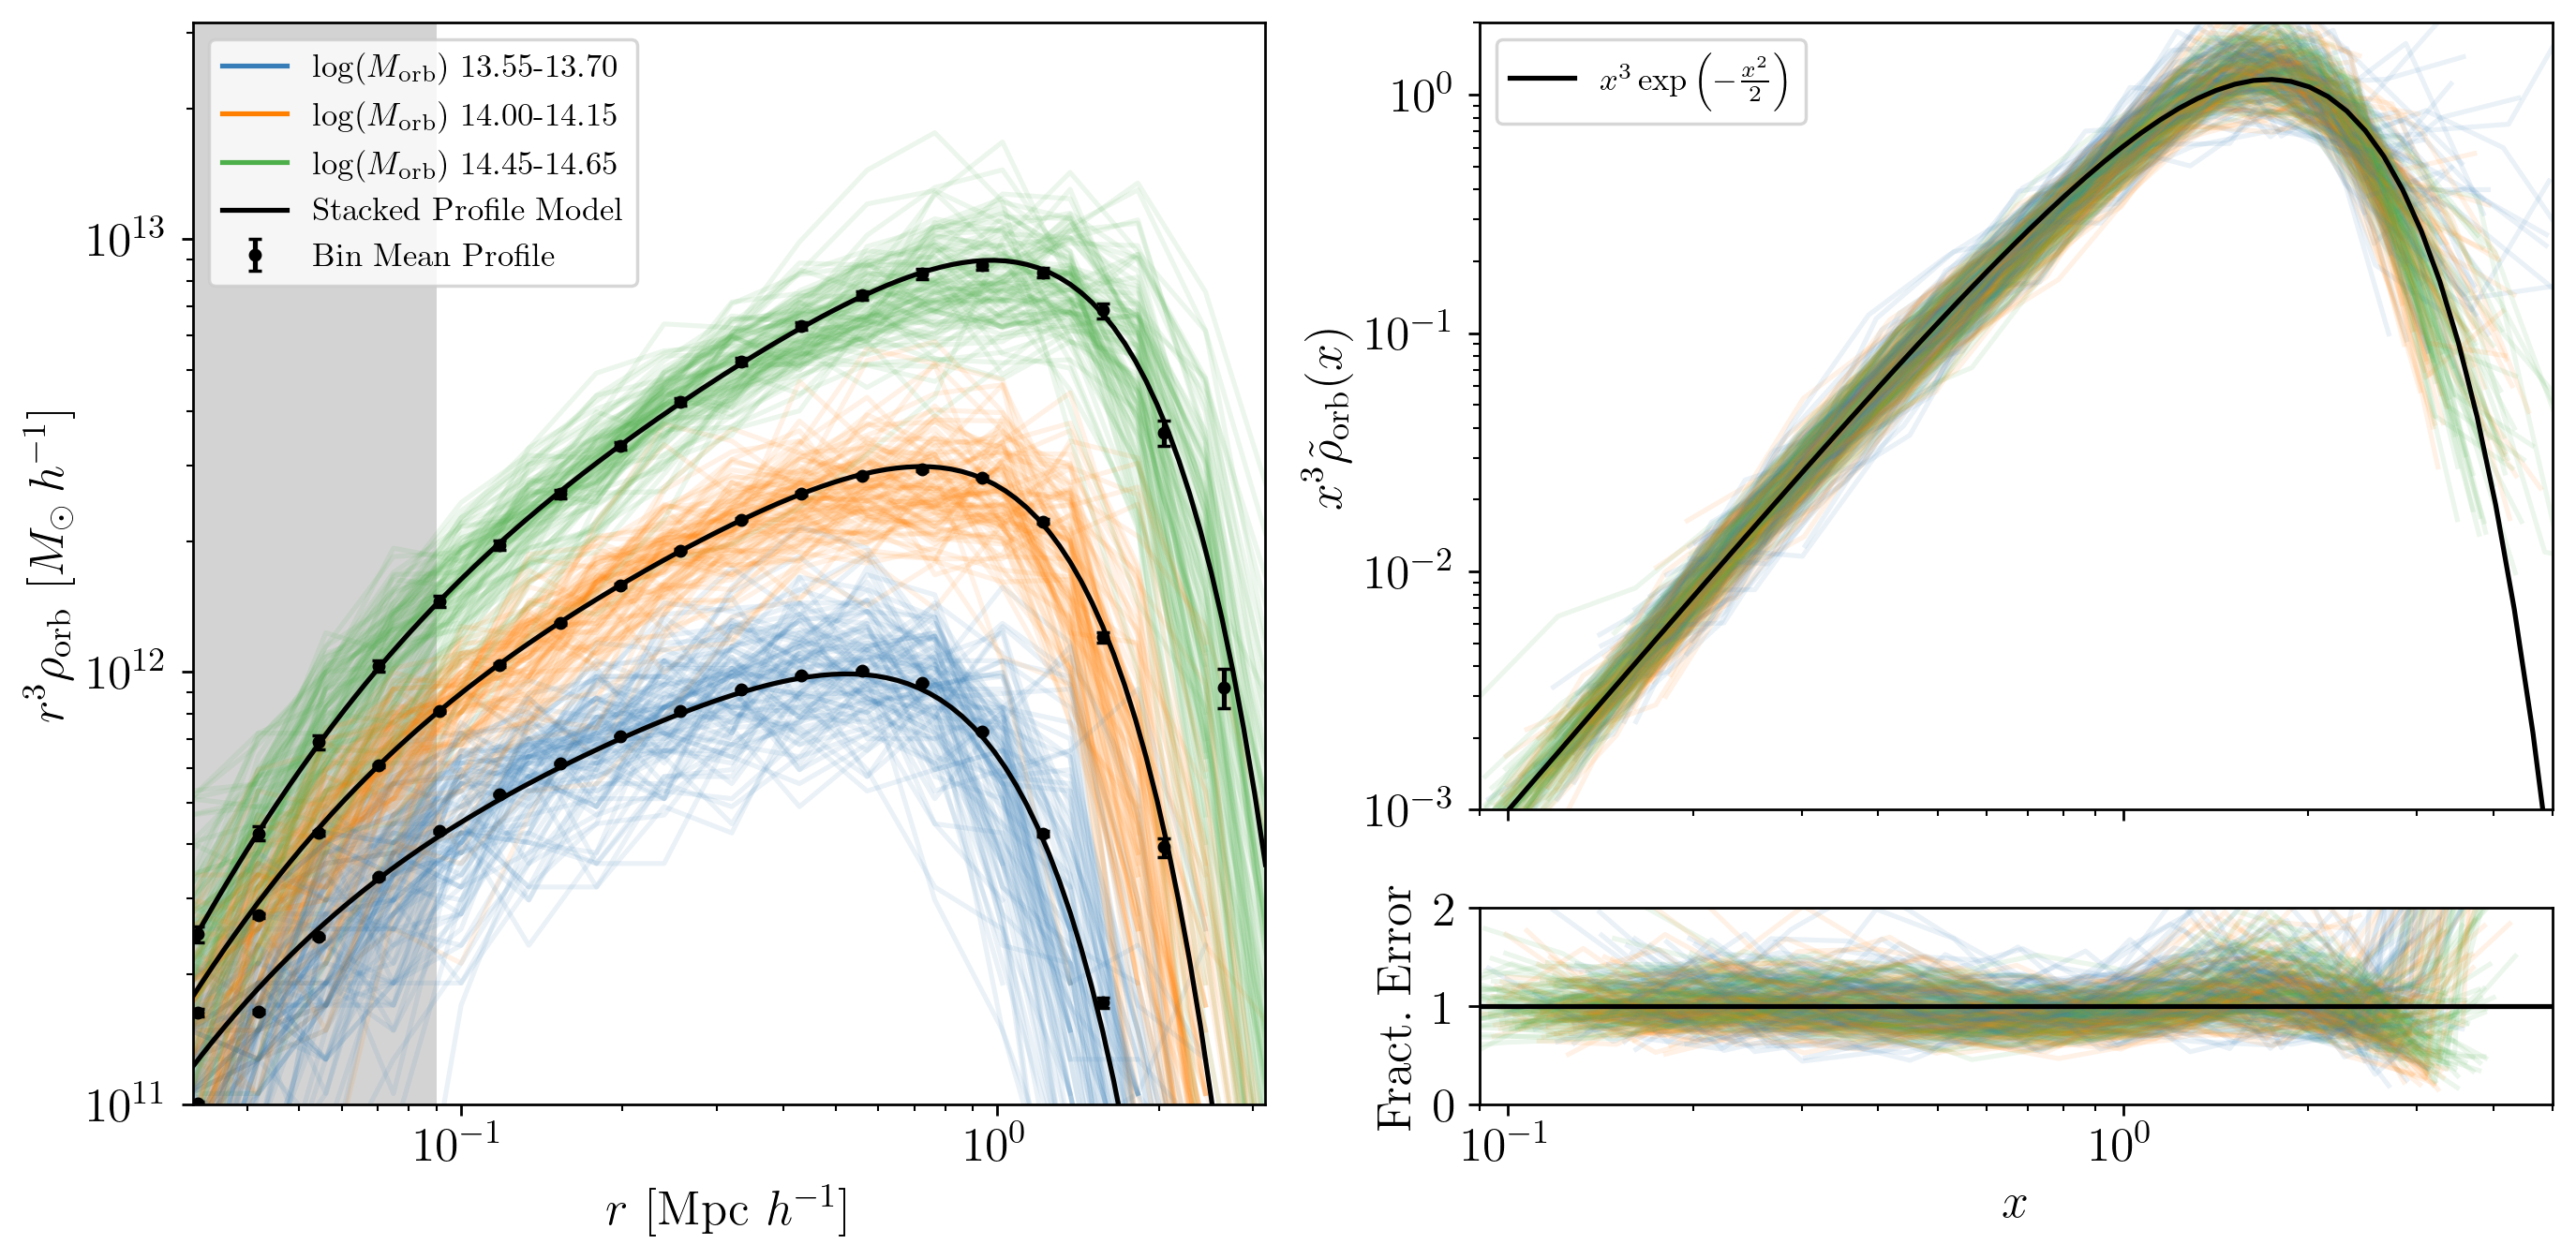

In [41]:
# FIGURE 1
latex()
fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 2, height_ratios=(4, 1))

# Three axes
ax1 = fig.add_subplot(gs[:, 0]) # Left panel
ax2 = fig.add_subplot(gs[0, 1]) # Top right panel
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2) # Bottom right panel

# Left panel (ax1, halo orbiting densities with stacked profiles)
for i in range(100):
    low_dens = low_mbin_dens[i, :]
    med_dens = med_mbin_dens[i, :]
    high_dens = high_mbin_dens[i, :]

    if i == 0:
        low_label = '$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[low_ind]
        med_label = '$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[med_ind]
        high_label = '$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[high_ind]
    else:
        low_label = None
        med_label = None 
        high_label = None

    ax1.loglog(RADIUS[low_dens > 0], (RADIUS[low_dens > 0] ** 3) * low_dens[low_dens > 0], color=COLORS[0], alpha=0.1, label=low_label)
    ax1.loglog(RADIUS[med_dens > 0], (RADIUS[med_dens > 0] ** 3) * med_dens[med_dens > 0], color=COLORS[1], alpha=0.1, label=med_label)
    ax1.loglog(RADIUS[high_dens > 0], (RADIUS[high_dens > 0] ** 3) * high_dens[high_dens > 0], color=COLORS[2], alpha=0.1, label=high_label)

# Stacked profile fit for each mass bin (black lines), with mean profiles represented by black dots + errorbars
r = np.logspace(-1.5, 0.5, num=100)
ax1.loglog(r, (r ** 3) * orb_model(r, 10 ** MASS[low_ind-1]), color='black', label='Stacked Profile Model')
ax1.loglog(r, (r ** 3) * orb_model(r, 10 ** MASS[med_ind-1]), color='black')
ax1.loglog(r, (r ** 3) * orb_model(r, 10 ** MASS[high_ind-1]), color='black')
ax1.errorbar(sal_r_bins, (sal_r_bins ** 3) * low_sal_dens, yerr=(sal_r_bins ** 3) * low_sal_err, color='black', fmt='.', capsize=2.0, label='Bin Mean Profile')
ax1.errorbar(sal_r_bins, (sal_r_bins ** 3) * med_sal_dens, yerr=(sal_r_bins ** 3) * med_sal_err, color='black', fmt='.', capsize=2.0)
ax1.errorbar(sal_r_bins, (sal_r_bins ** 3) * high_sal_dens, yerr=(sal_r_bins ** 3) * high_sal_err, color='black', fmt='.', capsize=2.0)

ax1.axvspan(xmin=0, xmax=6 * R_SOFT, facecolor='lightgray') # Color region masked from fitting

ax1.set_xlabel('$r$ [Mpc $h^{-1}$]', fontsize=15)
ax1.set_ylabel('$r^3 \\rho_{\\rm orb}$ [$M_{\\odot} \\: h^{-1}$]', fontsize=15)
ax1.set_ylim(10**11, 10**13.5)
ax1.set_xlim(10**(-1.5), 10**(0.5))
leg = ax1.legend(loc='upper left')
for lh in leg.legend_handles: 
    lh.set_alpha(1)



# Top right panel (ax2, fitted model)
for i in range(100):
    low_rho_tilde, low_x = orb_model_tilde(low_mbin_dens[i, :], low_Morb[i], low_mbin_rh[i], low_mbin_alph[i])
    med_rho_tilde, med_x = orb_model_tilde(med_mbin_dens[i, :], med_Morb[i], med_mbin_rh[i], med_mbin_alph[i])
    high_rho_tilde, high_x = orb_model_tilde(high_mbin_dens[i, :], high_Morb[i], high_mbin_rh[i], high_mbin_alph[i])

    low_mask = (low_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))
    med_mask = (med_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))
    high_mask = (high_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))

    ax2.loglog(low_x[low_mask], (low_x[low_mask] ** 3) * low_rho_tilde[low_mask], color=COLORS[0], alpha=0.1)
    ax2.loglog(med_x[med_mask], (med_x[med_mask] ** 3) * med_rho_tilde[med_mask], color=COLORS[1], alpha=0.1)
    ax2.loglog(high_x[high_mask], (high_x[high_mask] ** 3) * high_rho_tilde[high_mask], color=COLORS[2], alpha=0.1)

x = np.logspace(-2, 1, num=100)
ax2.loglog(x, (x ** 3) * np.exp(-(x ** 2) / 2), color='black', label='$x^3 \\exp \\left(-\\frac{x^2}{2} \\right)$')

ax2.set_ylabel('$x^3 \\tilde{\\rho}_{\\rm orb}(x)$', fontsize=15)
ax2.set_ylim(1e-3, 2)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.legend()



# Bottom right panel (fractional error)
for i in range(100):
    low_rho_tilde, low_x = orb_model_tilde(low_mbin_dens[i, :], low_Morb[i], low_mbin_rh[i], low_mbin_alph[i])
    med_rho_tilde, med_x = orb_model_tilde(med_mbin_dens[i, :], med_Morb[i], med_mbin_rh[i], med_mbin_alph[i])
    high_rho_tilde, high_x = orb_model_tilde(high_mbin_dens[i, :], high_Morb[i], high_mbin_rh[i], high_mbin_alph[i])

    low_mask = (low_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))
    med_mask = (med_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))
    high_mask = (high_rho_tilde > 0) & (RADIUS > (6 * R_SOFT))

    # Exponential models
    low_mod = np.exp(-(low_x ** 2) / 2)
    med_mod = np.exp(-(med_x ** 2) / 2)
    high_mod = np.exp(-(high_x ** 2) / 2)

    ax3.plot(low_x[low_mask], low_rho_tilde[low_mask] / low_mod[low_mask], color=COLORS[0], alpha=0.1)
    ax3.plot(med_x[med_mask], med_rho_tilde[med_mask] / med_mod[med_mask], color=COLORS[1], alpha=0.1)
    ax3.plot(high_x[high_mask], high_rho_tilde[high_mask] / high_mod[high_mask], color=COLORS[2], alpha=0.1)

ax3.plot(x, np.ones(shape=x.shape), color='black')

ax3.set_ylim(0, 2)
ax3.set_xlim(0.09, 5)

ax3.set_ylabel('$\\rm Fract. \\; Error$', fontsize=15)
ax3.set_xlabel('$x$', fontsize=15)

FIGURE 2: The color scale shows the number of dark matter halos in each pixel in the space of slope offset $\Delta\alpha_{\infty}$ (equation~\ref{eq:delta_alpha}) and rescaled halo radius (equation~\ref{eq:R}).  We see the inner slope of a halo is tightly correlated with the halo radius, a correlation we summarized by our best-fit line shown in red.

In [42]:
# Load R and delta alpha for every (massive) halo, calculated via fit_orbiting_profiles.py 
R = SIMULT_PARAMS['rh'][:] / SIMULT_PARAMS['rh_st'][:]
lnR = np.log(R)
delta_alph = SIMULT_PARAMS['alpha_inf'][:] - SIMULT_PARAMS['alpha_inf_st'][:]

In [43]:
# Fit a linear model to lnR vs delta alpha, maximizing number of haloes found within delta alpha=+- 0.03 of the line
result = minimize(num_cost, [1, 0], bounds=[(0.5, 1.5), (-0.5, 0.5)], method='simplex', args=(lnR, delta_alph))
s_alpha, alpha0 = result.x
s_alpha, alpha0

(1.0016474457286733, 0.04933732028434024)

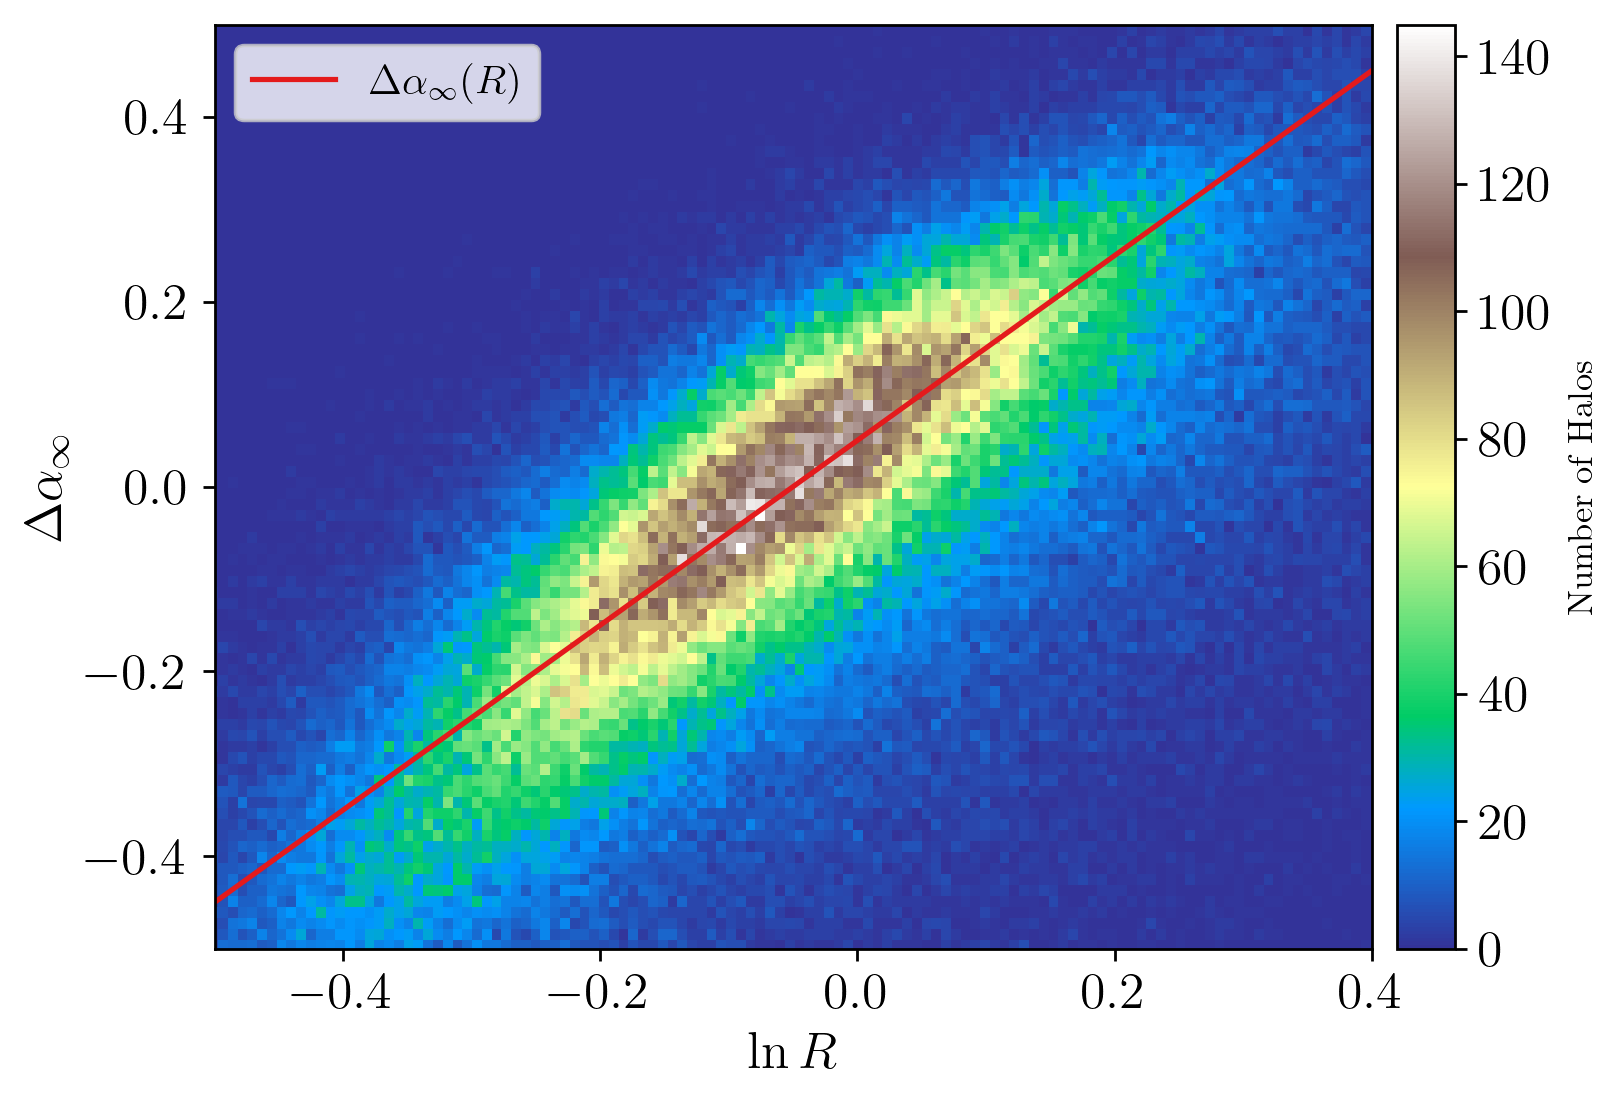

In [44]:
# FIGURE 2
plt.hist2d(lnR, delta_alph, bins=300, cmap='terrain')
x = np.linspace(-0.5, 0.4)
plt.plot(x, x + 0.05, color=COLORS[7], label='$\\Delta \\alpha_{\\infty}(R)$')

plt.legend(fontsize='large')
plt.xlim(-0.5, 0.4)
plt.ylim(-0.5, 0.5)
plt.xlabel('$\\ln R$', fontsize=15)
plt.ylabel('$\\Delta \\alpha_{\\infty}$', fontsize=15)

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes('right', size='5%', pad=0.1)

plt.colorbar(label='$\\rm Number \\; of \\; Halos$', cax=cax)

In [45]:
# For the rest of the analysis, we use "calibrated" profile fits, i.e. instead of fitting for rh and alpha simultaneously, we only fit for rh 
# and write alpha as a function of rh, shown in Fig. 2 above
R = CALIB_PARAMS['rh'][:] / CALIB_PARAMS['rh_st'][:]
lnR = np.log(R)

FIGURE 3. The distribution of $\ln R$ in bins of fixed mass.  We see that the halo radius $r_{\rm h}$ is roughly lognormally distributed, with an average value $<\ln R | M_{\rm orb}>=\ln 0.937 = -0.064$.  After accounting for particle noise, the intrinsic scatter in $\ln R$ at fixed mass is $\sigma_{\ln R | M_{\rm orb}}=0.16$.

0.9462443966478212
0.9454407698331507
0.92790339489545
0.9302402793576748


(0.9374572101835242, -0.06458416465012792)

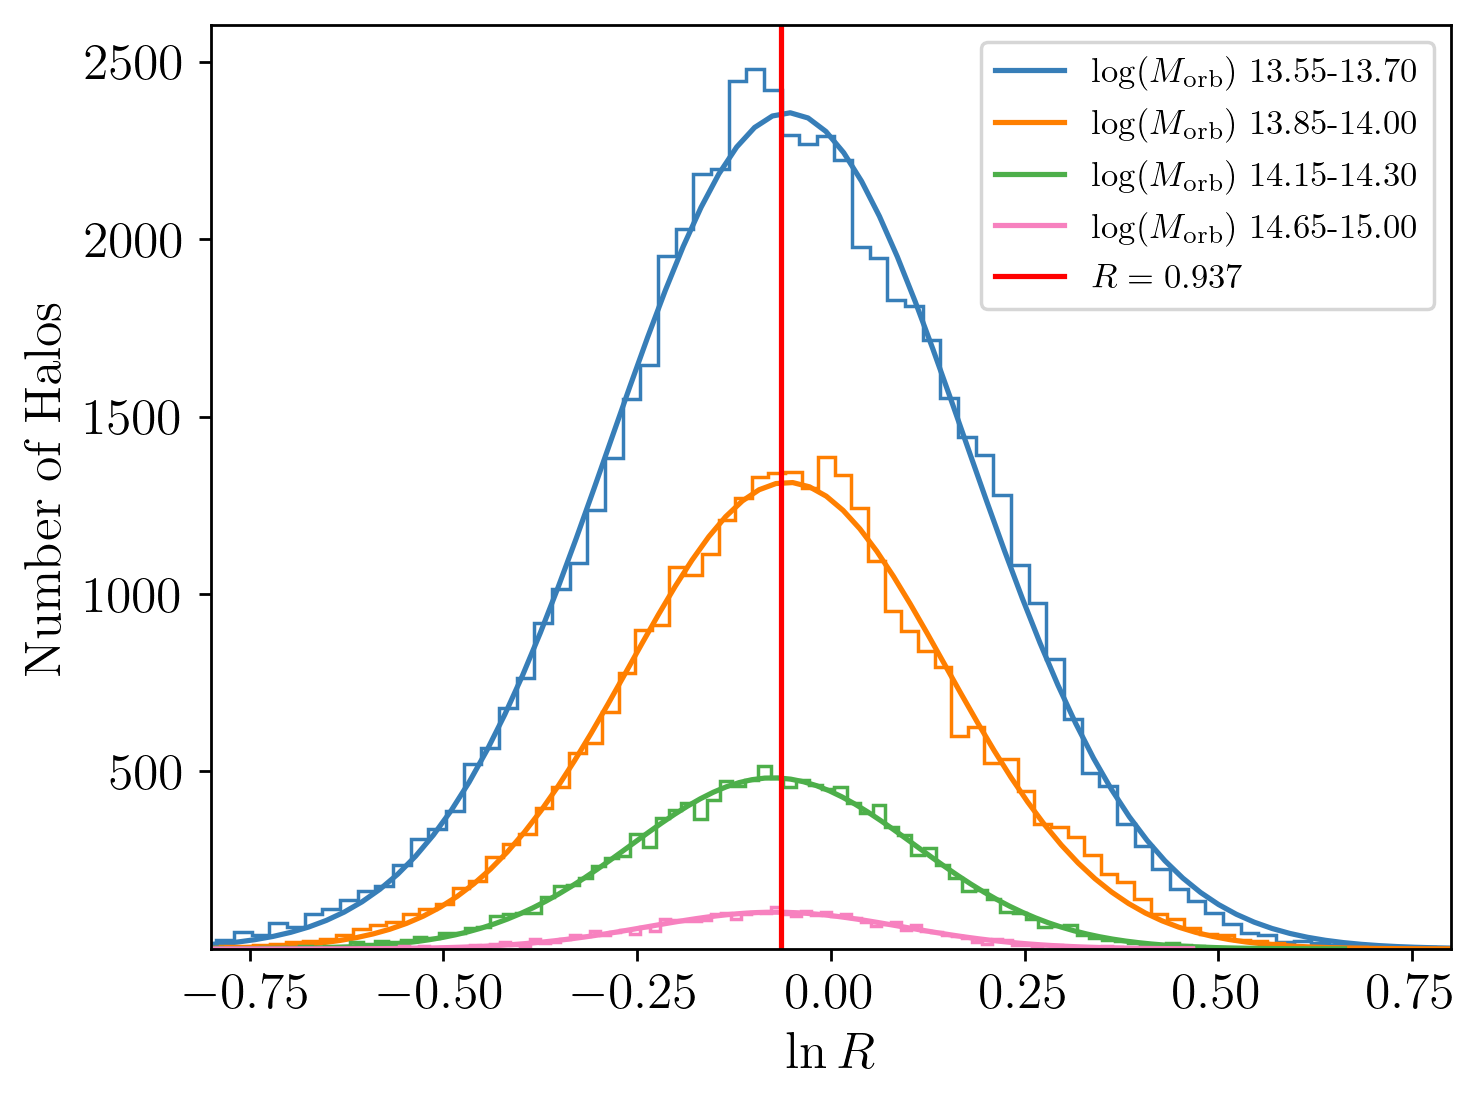

In [46]:
latex()

m = 0 # Color counter
Rmu = []
for i in [1, 3, 5, 8]:
    bin_lnR = lnR[mbin_indices == i]
    hist, bins, __ = plt.hist(bin_lnR, histtype='step', bins=100, color=COLORS[m])

    # Fit gaussian to each histogram and print exp(mean)
    x = np.linspace(np.min(bin_lnR), np.max(bin_lnR), num=100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, __ = curve_fit(fit_gaussian, bin_centers, hist, p0=[max(bin_lnR), np.mean(bin_lnR), np.std(bin_lnR)])
    amp, mu, sig = popt
    print(np.exp(mu))
    Rmu.append(np.exp(mu))
    plt.plot(x, fit_gaussian(x, amp, mu, sig), label='$\\log (M_{\\rm orb})$ ' + MASS_BIN_STRS[i], color=COLORS[m])
    m += 1

plt.axvline(np.log(0.937), color='red', label='$R = 0.937$')

plt.ylim(1)
plt.xlim(-0.8, 0.8)

plt.xlabel('$\\ln R$', fontsize=15)
plt.ylabel('Number of Halos', fontsize=15)

plt.legend()
np.average(Rmu), np.log(np.average(Rmu))

NOT IN PAPER. This plot validates the claim in Section III C that, after accounting for particle noise by fitting Eq. (14), the intrinsic scatter in $\ln R$ is 0.16

0.16444040659205178


/home/tdshield/orb_profiles/banerjee2020_sim/functions.py:240: RuntimeWarning: divide by zero encountered in divide
  return var0 + (k / N)


Text(0.5, 0, '$N$')

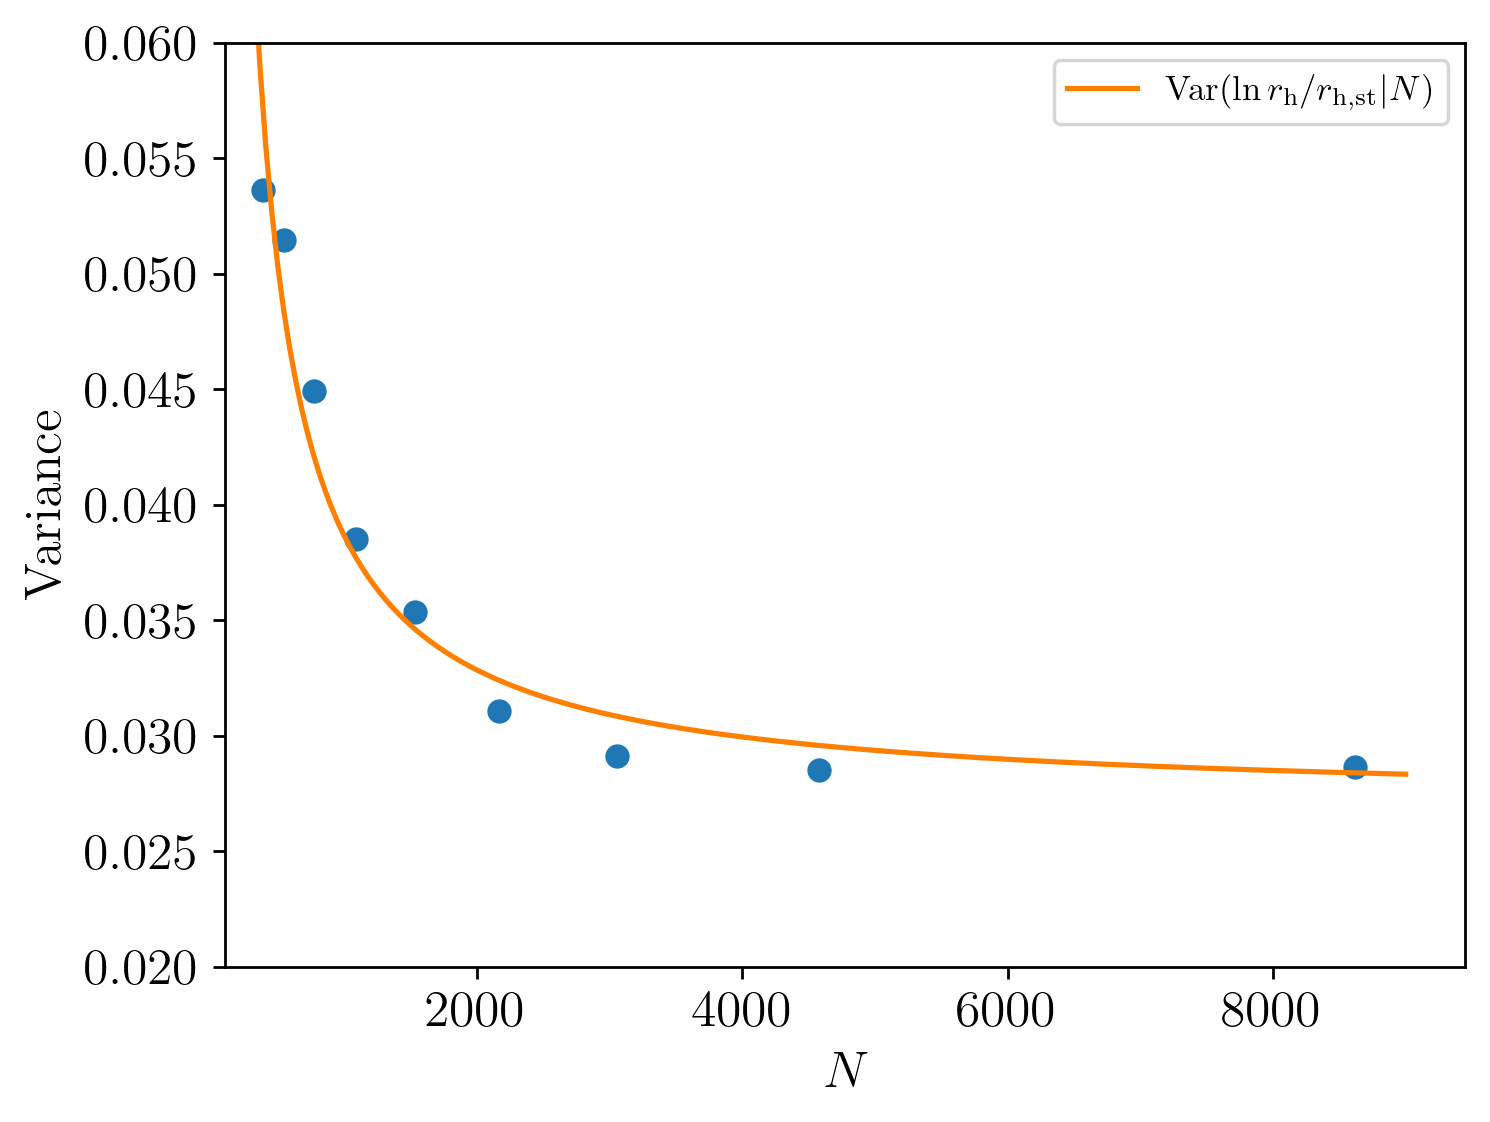

In [47]:
# Compute variance of lnR for each mass bin
var = np.zeros(len(MASS_BIN_STRS))
for i in range(1, 10):
    var[i-1] = np.var(lnR[mbin_indices == i])

N = (10 ** MASS) / PARTICLE_MASS # For each bin, take median Morb and convert to number of particles

# PLOT
latex()
plt.scatter(N, var)
popt, __ = curve_fit(var_R, N, var)
print(np.sqrt(popt[1])) # Best-fit value for intrinsic scatter
x = np.linspace(0, 9000, num=200)
plt.plot(x, var_R(x, popt[0], popt[1]), color=COLORS[1], label='${\\rm Var}(\\ln r_{\\rm h}/r_{\\rm h, st}|N)$')
plt.xlim(100)
plt.ylim(0.02, 0.06)
plt.legend()

plt.ylabel('Variance', fontsize=15)
plt.xlabel('$N$', fontsize=15)

NOT IN PAPER. Show binning process for $\ln R$, used in Figure 4.

In [48]:
# Bin lnR into bins of equal number of haloes
num_bins = 5
m = np.mean(lnR)
s = np.std(lnR)
lnR_bins = np.array([np.min(lnR), m - (2 * s), m - s, m, m + s, m + (2 * s), np.max(lnR)])
lnR_bins # Print bin edges for lnR

array([-1.18059024, -0.49188256, -0.27605469, -0.06022682,  0.15560106,
        0.37142893,  1.09861229])

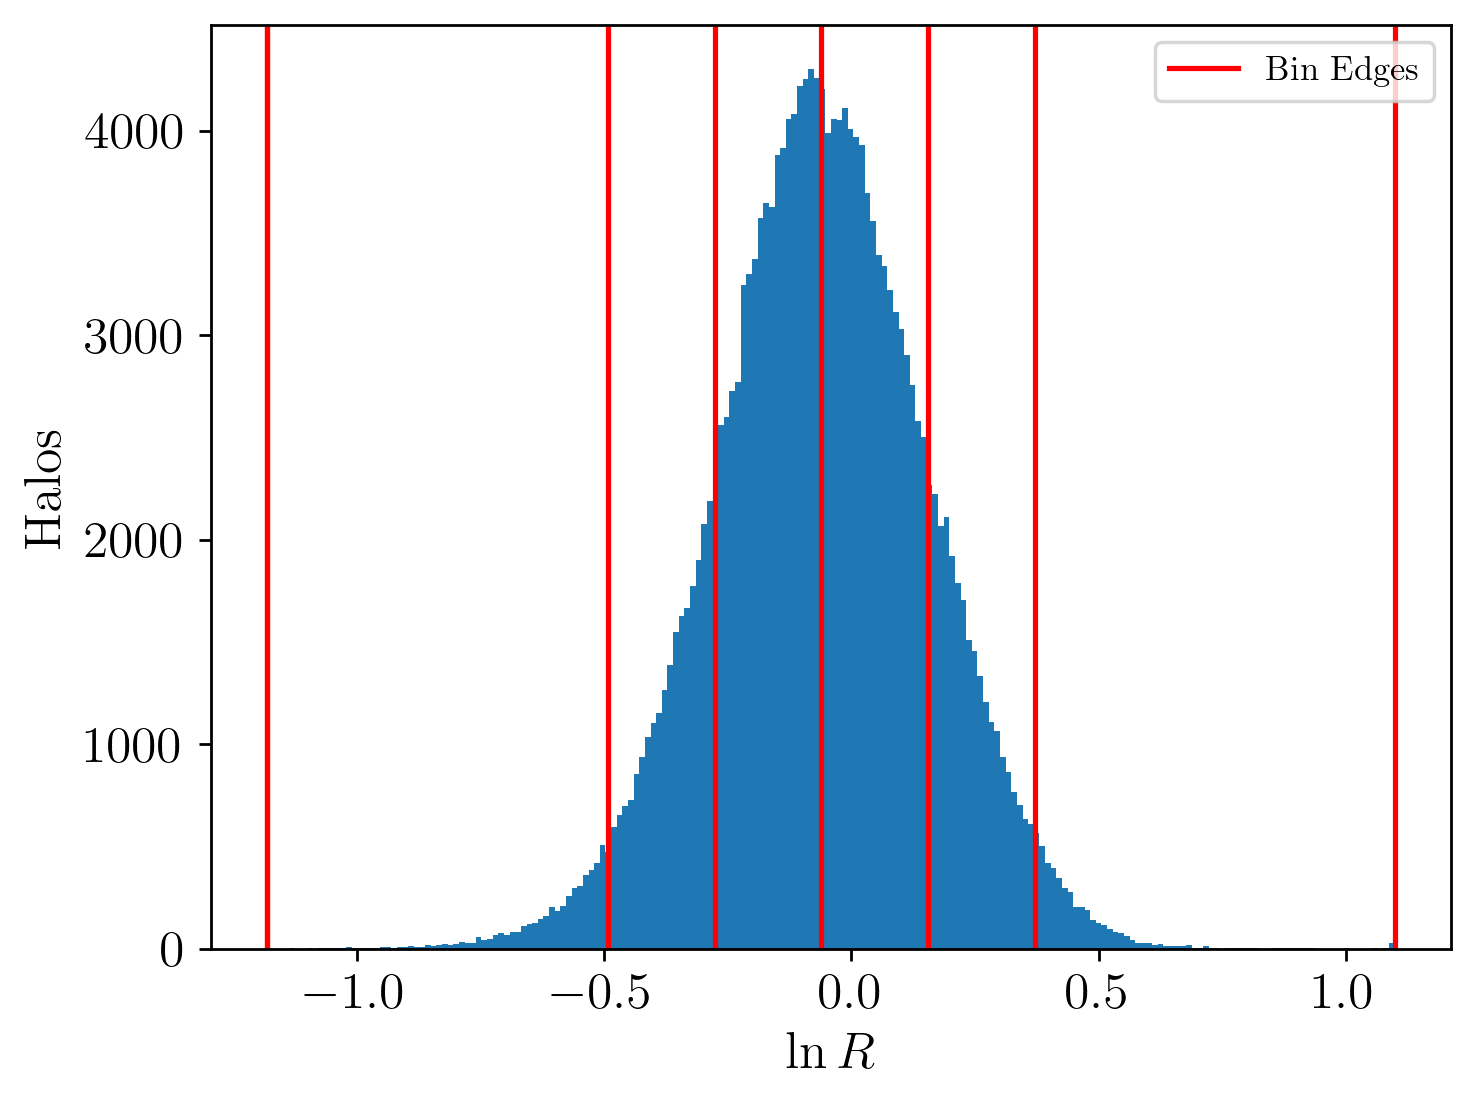

In [49]:
# Visually show the lnR bins
latex()

plt.hist(lnR, bins=200)
plt.axvline(lnR_bins[0], c='r', label='Bin Edges')
for i in range(len(lnR_bins)):
    plt.axvline(lnR_bins[i], c='r')

plt.xlabel('$\\ln R$', fontsize=15)
plt.ylabel('Halos', fontsize=15)
plt.legend()

FIGURE 4. After binning all of the haloes by $M_{\rm orb}$, then binning again by $\ln R$, we take CDFs of the particle accretion times of all the particles belonging to halos in those bins. A horizontal line is drawn when the CDF reaches 0.6, as at this point there is visually a clear distinction between most of the $\ln R$ bins that is approximately constant with mass.

In [50]:
# Load data for particle accretion times CDFs, calculated via compute_a_acc_by_halo.py
key_list = []
for i in range(len(LNR_BIN_EDGES) - 1):
    key_list.append(f'{LNR_BIN_EDGES[i]:.2f} < lnR < {LNR_BIN_EDGES[i+1]:.2f}')

P_a_acc = h5.File('/home/tdshield/shields_data_24/P_a_acc.hdf5', 'r')
P_a_acc[MASS_BIN_STRS[0] + '/' + key_list[0]]

__, a_acc_bins = np.histogram(PARTICLE_A_ACC['a_inf'][()], bins=200) # Create CDFs in form of histograms

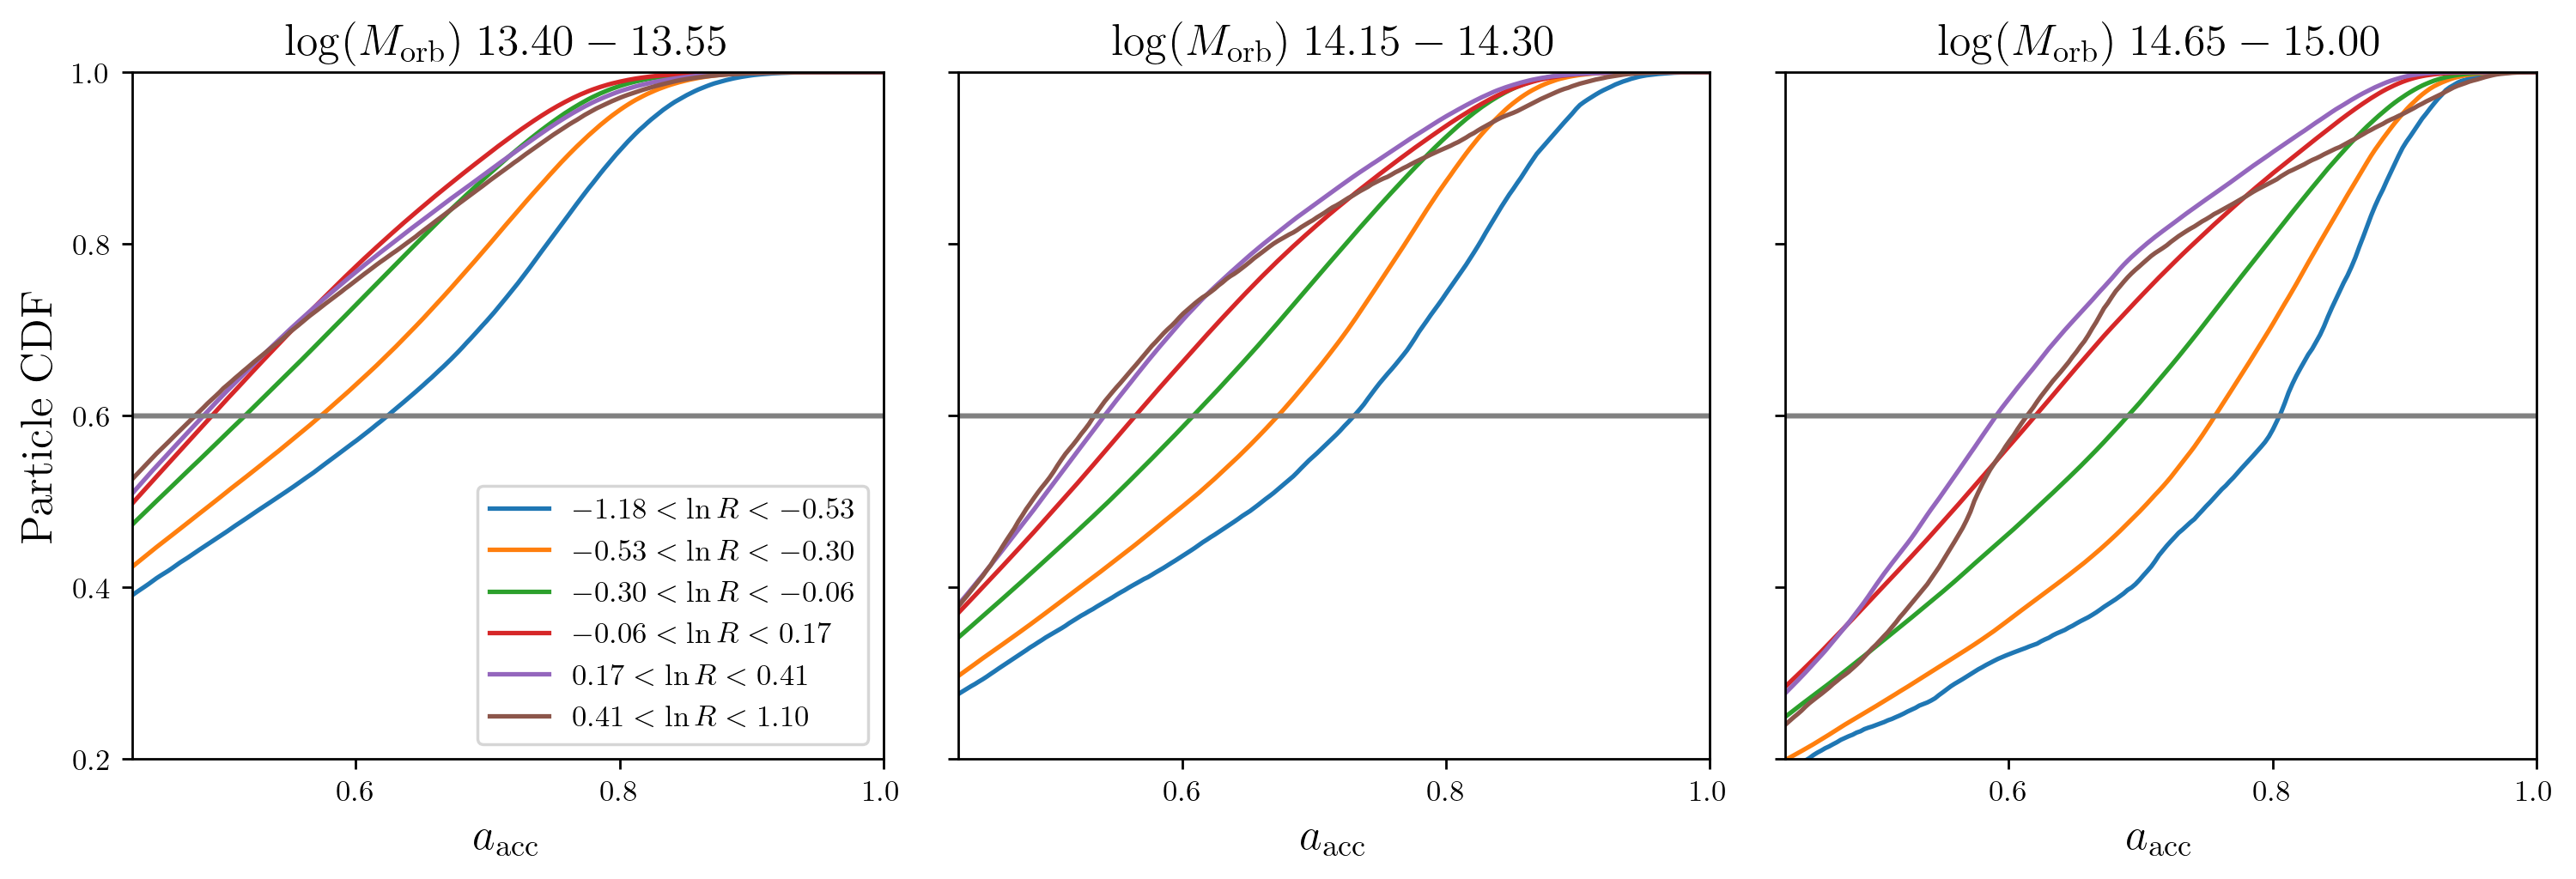

In [51]:
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
latex()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.1,
                    hspace=0.4)

i = 0
ind = [0, 5, 8]
for col in range(3):
    for j in range(6):
        da = np.diff(a_acc_bins)[0]
        P = P_a_acc[MASS_BIN_STRS[ind[i]] + '/' + key_list[j]][:]
        P_unity = P / P.sum()

        if i == 0:
            axes[col].plot(a_acc_bins[1:], P_unity.cumsum(), label=f'${LNR_BIN_EDGES[j]:.2f} < \\ln R < {LNR_BIN_EDGES[j+1]:.2f}$')
        else:
            axes[col].plot(a_acc_bins[1:], P_unity.cumsum())

        axes[col].set_title(f'$\\log(M_{{\\rm orb}}) \\; {MASS_BIN_STRS[ind[i]]}$', fontsize=15, )
        axes[col].set_xlabel('$a_{\\rm acc}$', fontsize=15)

        axes[col].set_xlim(0.43, 1.0)
        axes[col].set_ylim(0.2, 1.0)

        axes[col].axhline(0.6, color='gray')
    i += 1
axes[0].legend()
axes[0].set_ylabel('Particle CDF', fontsize=15)

rcParams['xtick.labelsize'] = 15
rcParams['ytick.labelsize'] = 15

FIGURE 5. {\bf Left:} Correlation between halo radius (equation~\ref{eq:R}) and a halo's relative formation time (equation~\ref{eq:a_RF_defn}) at fied mass, for halos of mass $M_{\rm orb} > 10^{14} M_{\odot}$. Our best fit line for this correlation is shown in red. {\bf Right:} Correlation between halo radius at fixed halo mass, as a function of halo accretion rate divided by halo virial mass. The qualitative trends is similar to that of the left panel, though the relation with accretion rate exhibits large tails.

In [52]:
# Using the a60 parameters of each halo, compute the relative formation parameter aRF for every halo more massive than 1e+14 Msun
a60 = np.load('/home/tdshield/shields_data_24/halo_a60.npy', allow_pickle=True) 
Morb_mask = np.log10(Morb) > 14 # Mask for halos that have resolved a_acc times

# aRF is simply computed by taking all a60 values in a given mass bin, then dividing each a60 value by the mass bin's median a60
aRF = np.zeros(len(a60))
for i in range(1, 10):
    mask = (mbin_indices == i)
    aRF[mask] = a60[mask] / np.median(a60[mask])

In [53]:
# Fit a line using the same model as in Figure 2
result = minimize(num_cost, [-1.0, 1.9], bounds=[(-1.2, -0.5), (1.5, 2)], method='simplex', args=(aRF[Morb_mask], R[Morb_mask]))
s_a, a0 = result.x
s_a, a0

(-0.9816334085486722, 1.891525178972526)

In [54]:
# Redo fit, but force the slope to be -1
result = minimize(num_cost, [-1.0, 1.9], bounds=[(-1.001, -0.999), (1.5, 2)], method='simplex', args=(aRF[Morb_mask], R[Morb_mask]))
s_a, a0 = result.x
s_a, a0

(-0.9990766820299374, 1.9093648196924191)

/tmp/ipykernel_2035827/302186043.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


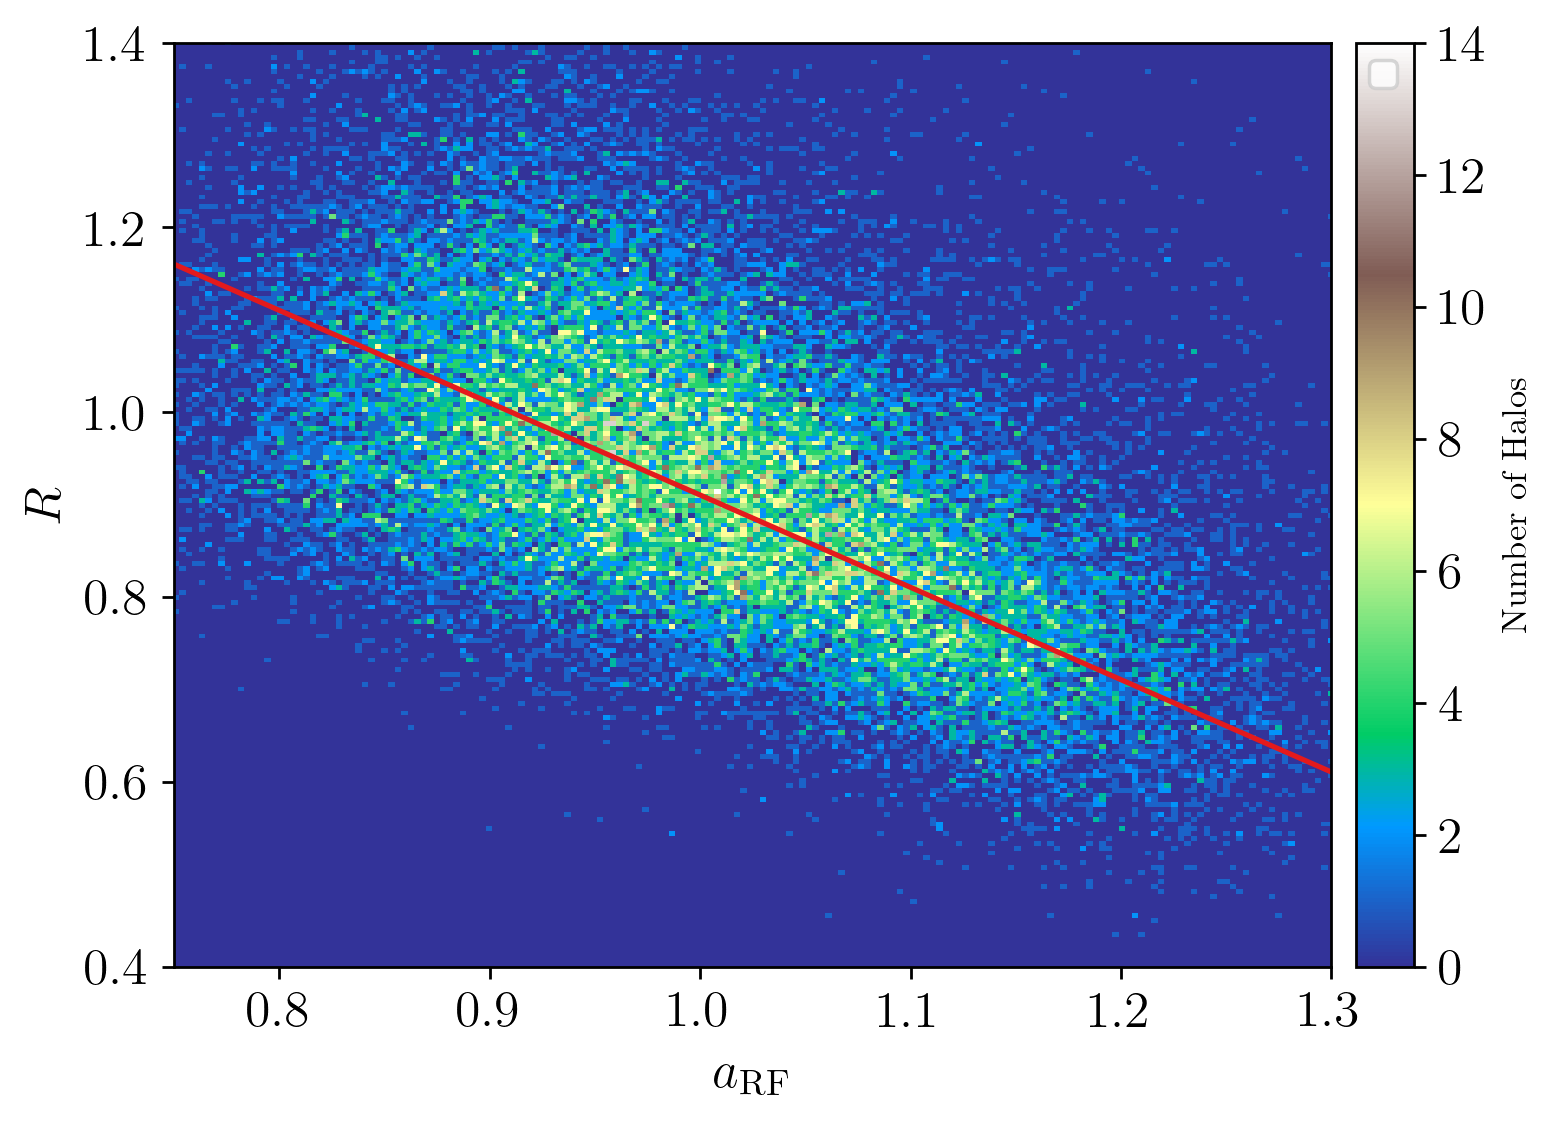

In [55]:
# LEFT OF FIGURE 5
latex()

plt.hist2d(aRF[Morb_mask], R[Morb_mask], bins=300, cmap='terrain')
x = np.linspace(0.7, 1.3)
plt.plot(x, line(x, s_a, a0), color=COLORS[7], label='$\\a_{\\rm RF}(R)$')

plt.xlabel('$a_{\\rm RF}$', fontsize=15)
plt.ylabel('$R$', fontsize=15)

plt.ylim(0.4, 1.4)
plt.xlim(0.75, 1.3)

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes('right', size='5%', pad=0.1)

plt.legend()
plt.colorbar(label='Number of Halos', cax=cax)

In [56]:
# Load accretion rate data from original ROCKSTAR halo catalog
rs_mask = np.isin(ROCKSTAR_CATALOG['Orig_halo_ID'][()], hids)
rs_hids = ROCKSTAR_CATALOG['Orig_halo_ID'][rs_mask]

# Match order of halo IDs
R_sort = R[np.argsort(hids)]
rh_sort = CALIB_PARAMS['rh'][np.argsort(hids)]
Morb_sort = Morb[np.argsort(hids)]
acc_rate_2tdyn = ROCKSTAR_CATALOG['Acc_Rate_2*Tdyn'][rs_mask][np.argsort(rs_hids)]
rs_Mvir = ROCKSTAR_CATALOG['Mvir'][rs_mask][np.argsort(rs_hids)]
acc_rate = acc_rate_2tdyn / rs_Mvir 

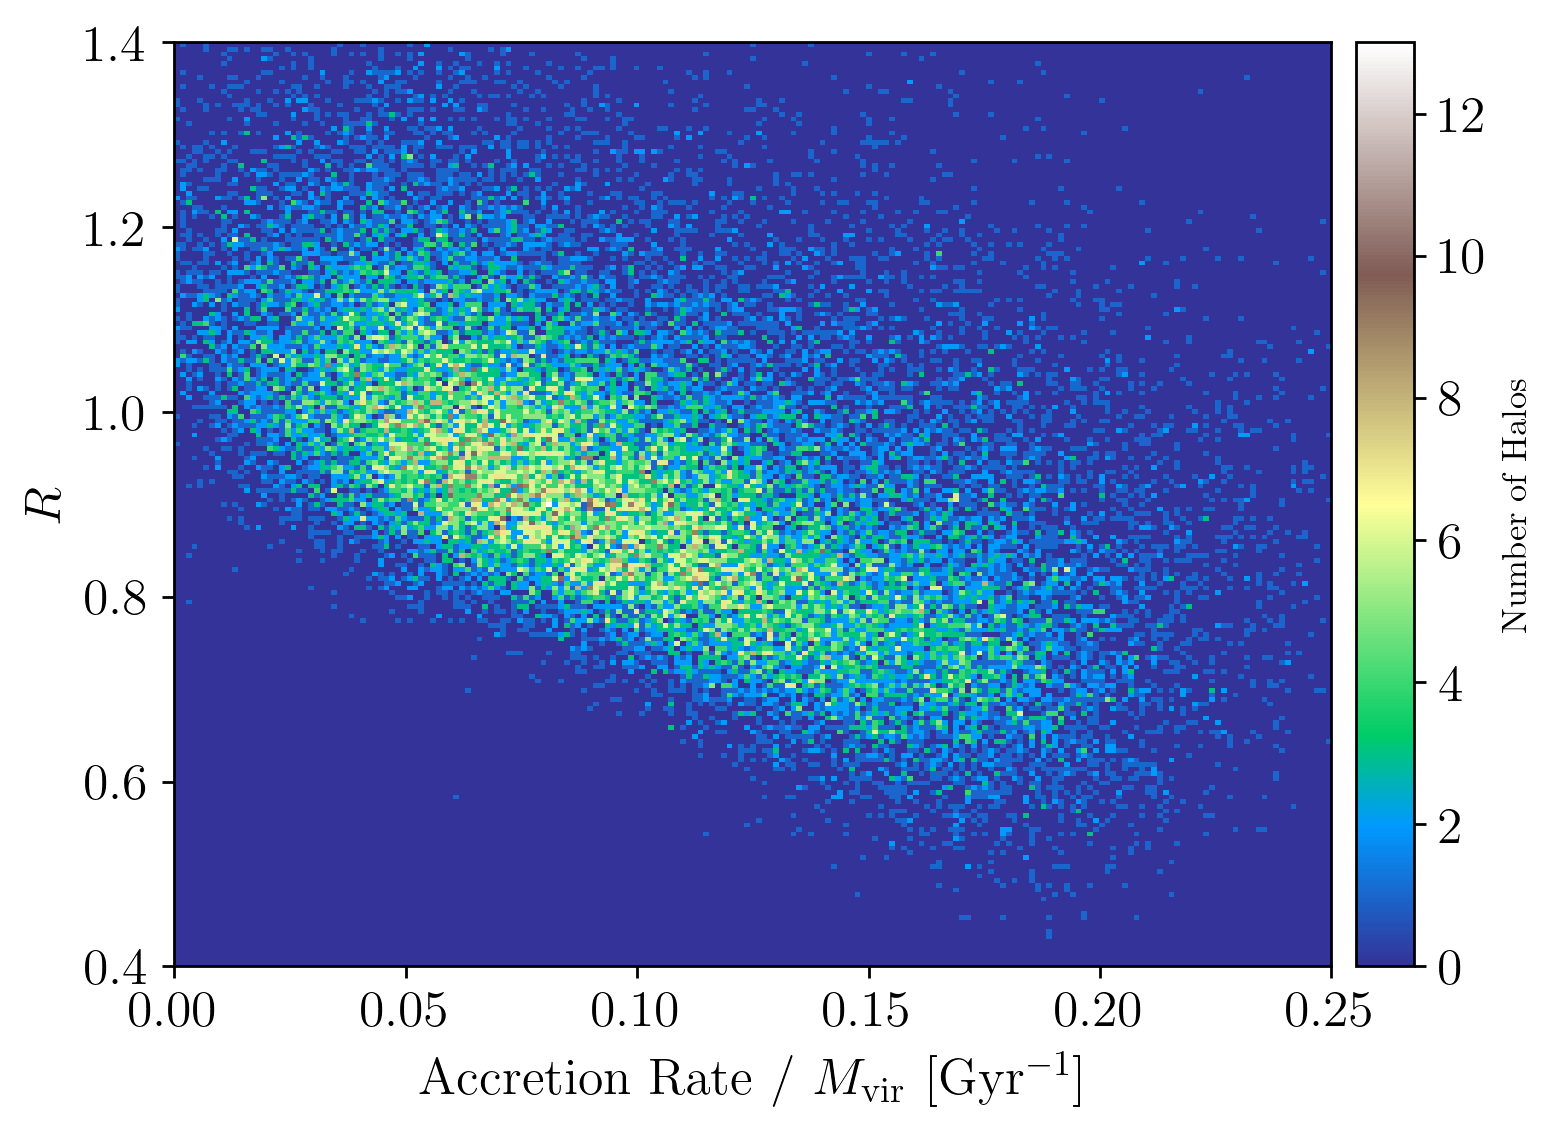

In [57]:
# RIGHT OF FIGURE 5
latex()

# Set tick label size
rcParams['xtick.labelsize'] = 15
rcParams['ytick.labelsize'] = 15

plt.hist2d(acc_rate[Morb > 1e+14]*1e+9, R[Morb > 1e+14], bins=[np.linspace(0, 2.5e-1, num=200), np.linspace(0.4, 1.4, num=200)], cmap='terrain')

plt.xlim(0)

plt.ylabel('$R$', fontsize=15)
plt.xlabel('Accretion Rate / $M_{\\rm vir}$ [Gyr$^{-1}$]', fontsize=15)

divider = make_axes_locatable(plt.gca())
cax = divider.append_axes('right', size='5%', pad=0.1)

plt.colorbar(label='$\\rm Number \\; of \\; Halos$', cax=cax)

NOT IN PAPER. Verify claim that the expectation value of $\ln r_{\rm h} / r_{\rm mod}$ is 0.018 with an intrinsic scatter of 0.111

0.01788687766062933
0.0032043606585991473


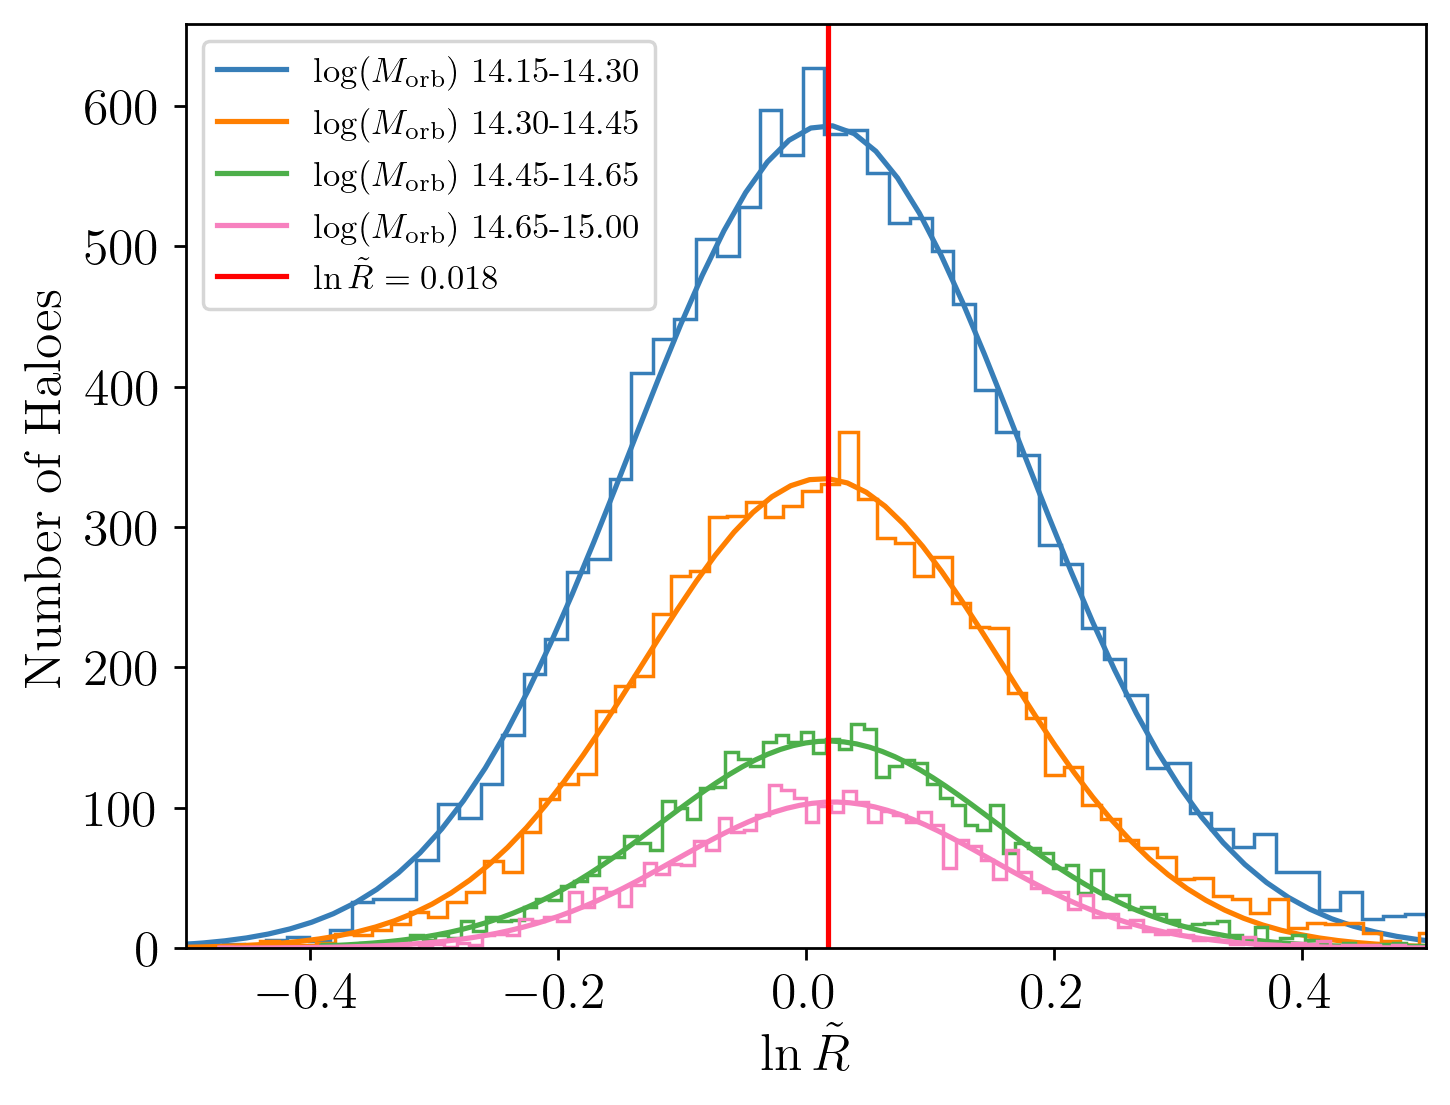

In [58]:
# Show Figure 3 but for rh/rh_mod
rh_fit = CALIB_PARAMS['rh'][()]
rh_st_data = CALIB_PARAMS['rh_st'][()]
rh_mod = (ARF_0 + (S_ARF * aRF[Morb_mask])) * rh_st_data[Morb_mask]

latex()

m = 0 # Color counter
mu = np.zeros(4)
for i in [5, 6, 7, 8]:
    bin_lnR = np.log((rh_fit[Morb_mask] / rh_mod)[mbin_indices[Morb_mask] == i])
    hist, bins, __ = plt.hist(bin_lnR, histtype='step', bins=100, color=COLORS[m])

    # Fit gaussian to each histogram
    x = np.linspace(np.min(bin_lnR), np.max(bin_lnR), num=100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, __ = curve_fit(fit_gaussian, bin_centers, hist, p0=[max(bin_lnR), np.mean(bin_lnR), np.std(bin_lnR)])
    amp, mui, sig = popt
    mu[m] = mui
    plt.plot(x, fit_gaussian(x, amp, mui, sig), label='$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[i], color=COLORS[m])
    m += 1

plt.axvline(np.average(mu), color='red', label=f'$\\ln \\tilde{{R}} = {np.average(mu):.3f}$')

plt.xlim(-0.5, 0.5)

plt.xlabel('$\\ln \\tilde{R}$', fontsize=15)
plt.ylabel('Number of Haloes', fontsize=15)

plt.legend()
print(np.average(mu))
print(np.std(mu))

0.11151355643415885


Text(0.5, 0, '$N$')

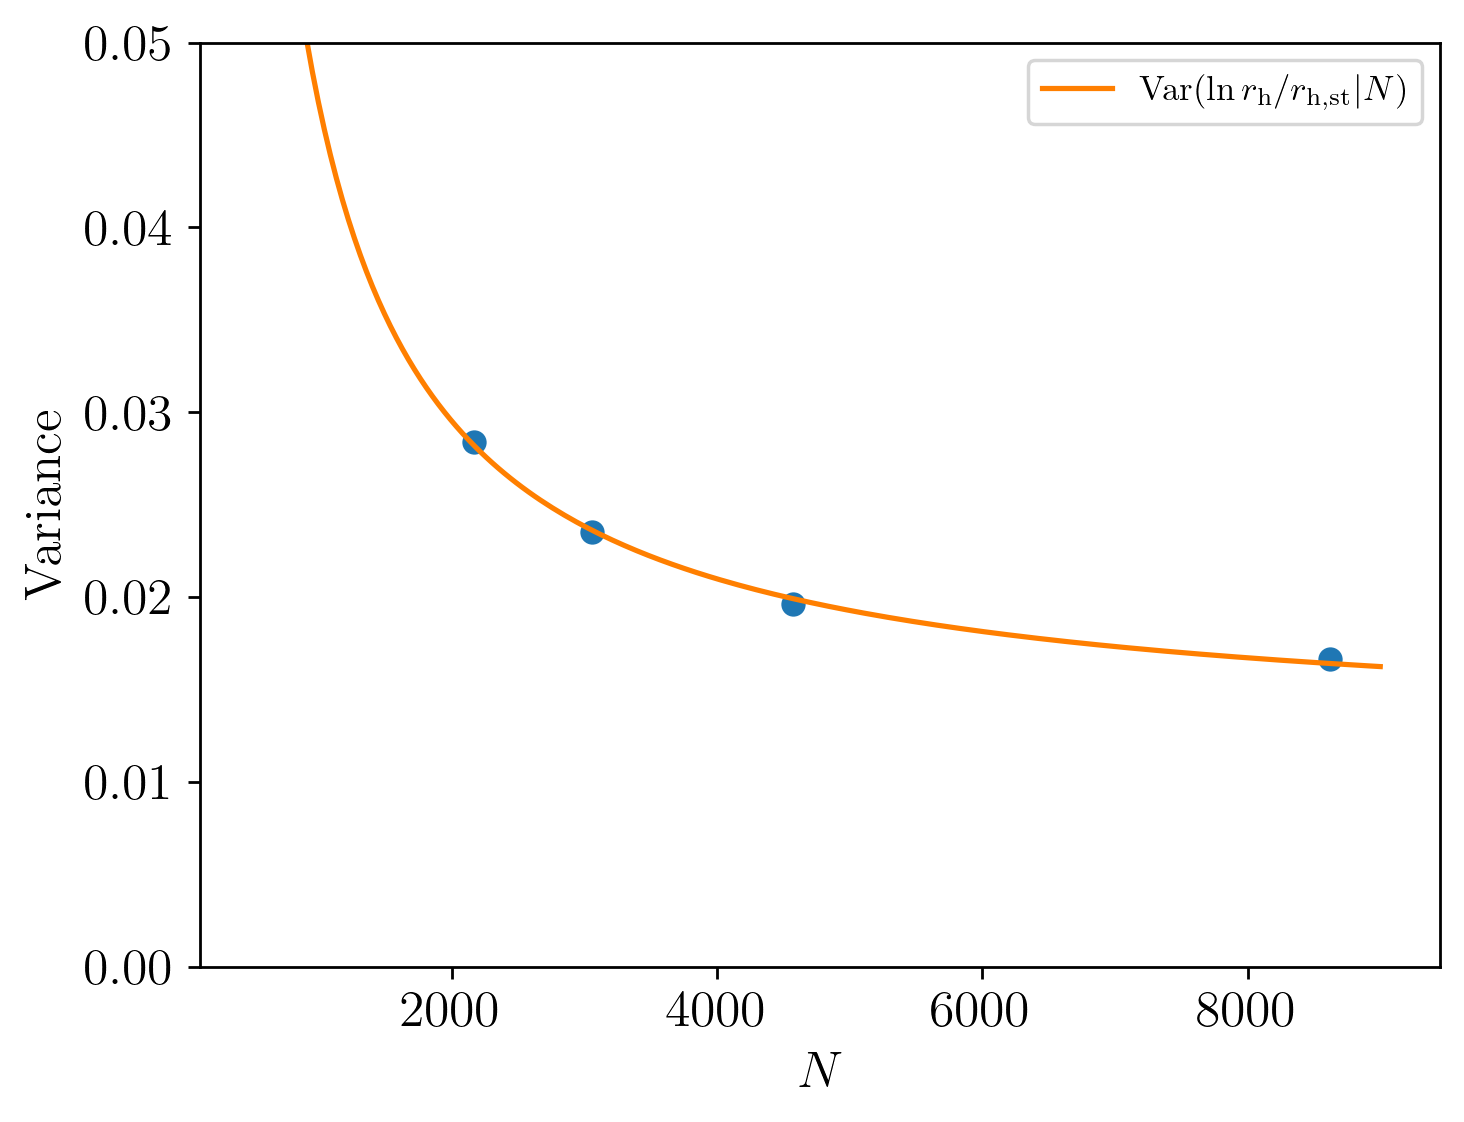

In [59]:
# Show the variance fit for ln rh/rh_mod
var = np.zeros(4)
j = 0
for i in [5, 6, 7, 8]:
    var[j] = np.var(np.log((rh_fit[Morb_mask] / rh_mod)[mbin_indices[Morb_mask] == i]))
    j += 1

N = (10 ** MASS) / PARTICLE_MASS

latex()
plt.scatter(N[5:], var)
popt, __ = curve_fit(var_R, N[5:], var)
print(np.sqrt(popt[1]))
x = np.linspace(0, 9000, num=200)
plt.plot(x, var_R(x, popt[0], popt[1]), color=COLORS[1], label='${\\rm Var}(\\ln r_{\\rm h}/r_{\\rm h, st}|N)$')
plt.xlim(100)
plt.ylim(0, 0.05)
plt.legend()

plt.ylabel('Variance', fontsize=15)
plt.xlabel('$N$', fontsize=15)

NOT IN PAPER. Verify that, when using best-fit halo radius with $\alpha_{\infty}$ as a free parameter and using Figure 2 as our model to predict $r_{\rm h}$, there is a core with about 5\% intrinsic scatter.

0.08882486047105691
0.08320361012262752
0.07843798605336026
0.07399081641446582
0.07032498011709941
0.06579195844256167
0.06203533339798588
0.05868206689420049
0.05481789059146536


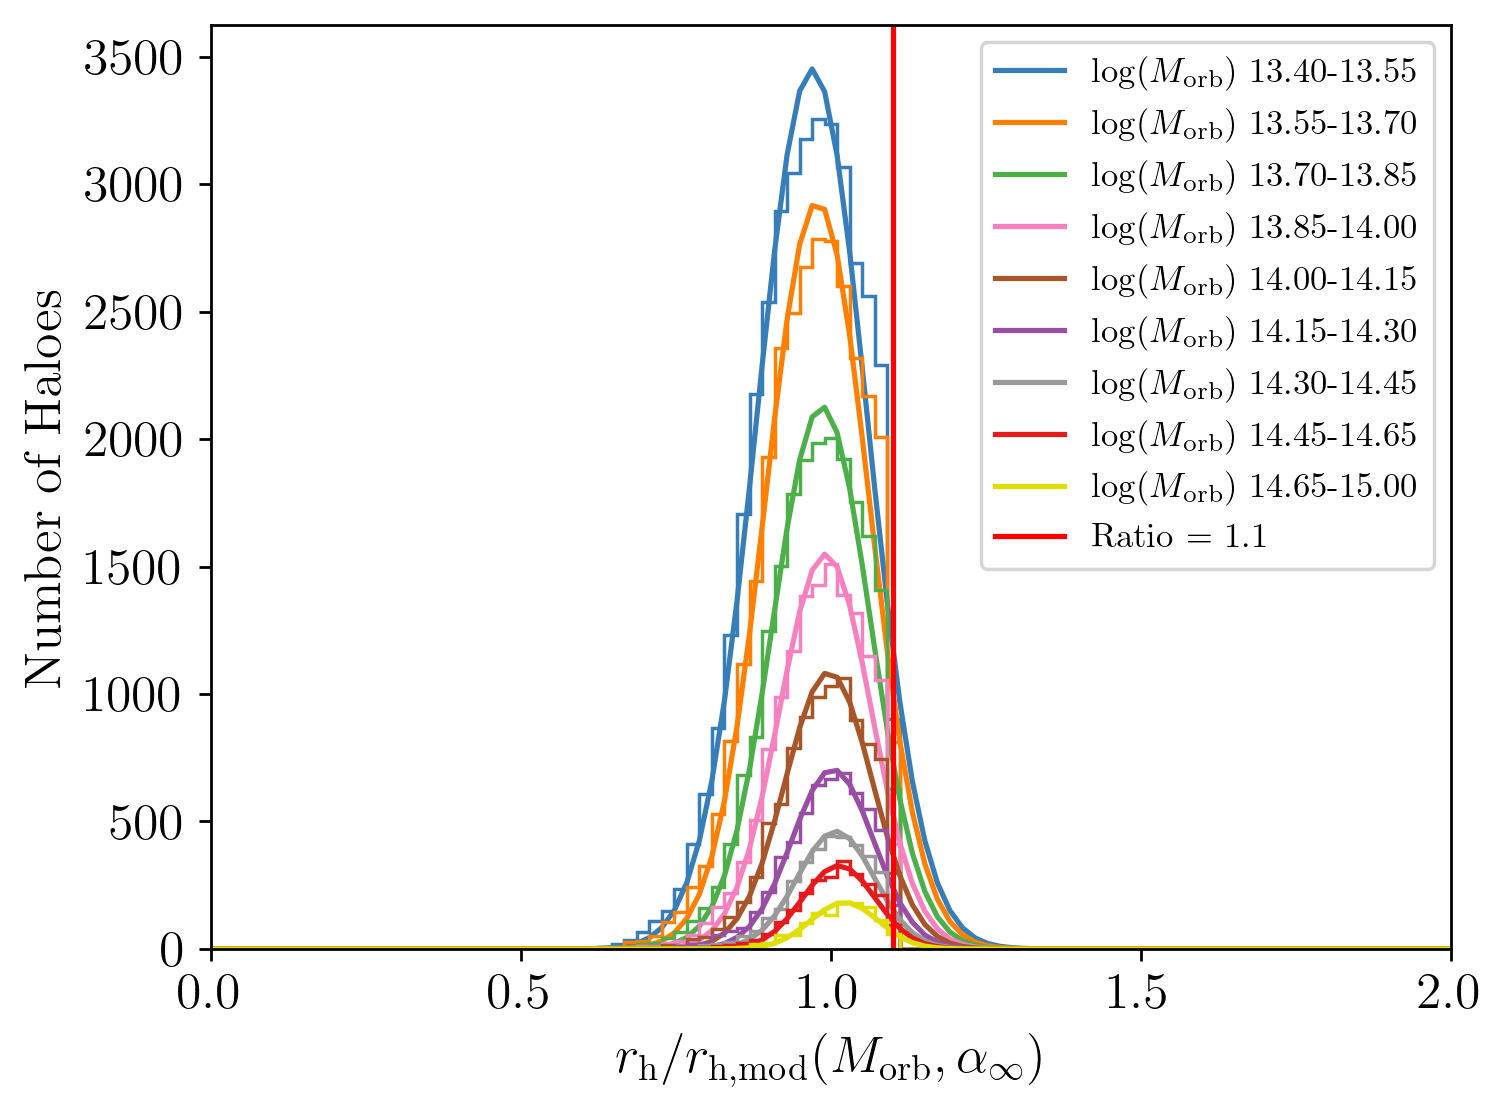

In [60]:
# New rmod that takes in alpha_inf as a parameter
def rmod(Morb, alpha_inf):
    return rh_st(Morb) * np.exp((alpha_inf - alpha_inf_st(Morb) - ALPHA_0) / S_ALPHA)

alpha_inf_sim = SIMULT_PARAMS['alpha_inf'][()]
Morb = HALO_CATALOG['Morb'][HALO_MASS_MASK][:192042]
rh_fit = SIMULT_PARAMS['rh'][()]
rh_mod = rmod(Morb, alpha_inf_sim)


# PLOT distributions
latex()

m = 0 # Color counter
mu = np.zeros(9)
std = np.zeros(9)
for i in range(1, 10):
    R_alph = (rh_fit / rh_mod)[mbin_indices == i]
    bin_ratio = R_alph[(R_alph > 0.6) & (R_alph < 1.1)]
    hist, bins, __ = plt.hist(bin_ratio, histtype='step', bins=np.linspace(0, 2, num=100), color=COLORS[m])

    # Fit gaussian to each histogram
    x = np.linspace(0, 2, num=100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, __ = curve_fit(fit_gaussian, bin_centers, hist, p0=[np.max(bin_ratio), np.mean(bin_ratio), np.std(bin_ratio)])
    amp, mui, sig = popt
    print(np.abs(sig))
    mu[m] = mui
    std[m] = np.abs(sig)
    plt.plot(x, fit_gaussian(x, amp, mui, sig), label='$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[i-1], color=COLORS[m])
    m += 1

plt.axvline(1.1, color='red', label='Ratio = 1.1')

# plt.yscale('log')
plt.xlim(0, 2)

plt.xlabel('$r_{\\rm h} / r_{\\rm h, mod}(M_{\\rm orb}, \\alpha_{\\infty})$', fontsize=15)
plt.ylabel('Number of Haloes', fontsize=15)

plt.legend()

0.0574995776632417


Text(0.5, 0, '$N$')

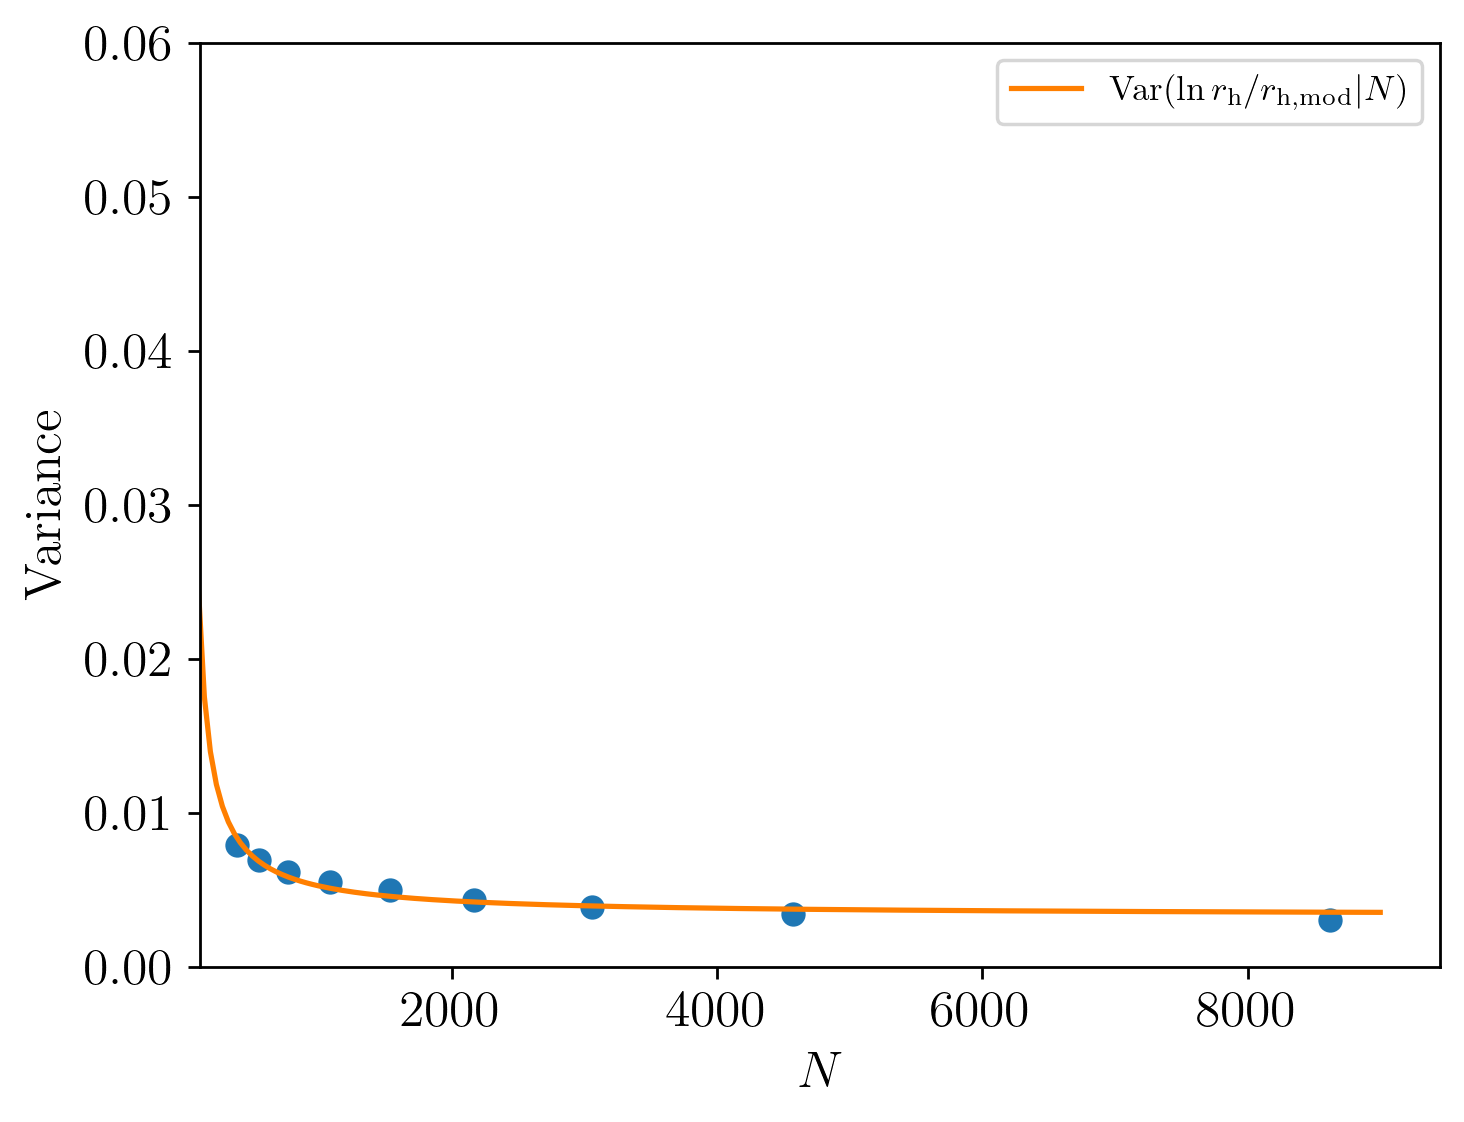

In [61]:
N = (10 ** MASS) / PARTICLE_MASS

var = std ** 2
latex()
plt.scatter(N, var)
popt, __ = curve_fit(var_R, N, var)
print(np.sqrt(popt[1]))
x = np.linspace(0, 9000, num=200)
plt.plot(x, var_R(x, popt[0], popt[1]), color=COLORS[1], label='${\\rm Var}(\\ln r_{\\rm h}/r_{\\rm h, mod}|N)$')
plt.xlim(100)
plt.ylim(0, 0.06)
plt.legend()

plt.ylabel('Variance', fontsize=15)
plt.xlabel('$N$', fontsize=15)

NOT IN PAPER. With the distribution of aRF in bins of mass, test self-consistency of the model (see Eqns (20)-(22)).

0.0018087960529664336
-0.6647977644170122
0.11703349852907882
0.18369466657306582


/home/tdshield/orb_profiles/banerjee2020_sim/functions.py:244: RuntimeWarning: invalid value encountered in log
  return (1 / (np.sqrt(2 * np.pi) * S * (x - a))) * np.exp(-((np.log(x - a) - M) ** 2) / (2 * (S ** 2)))


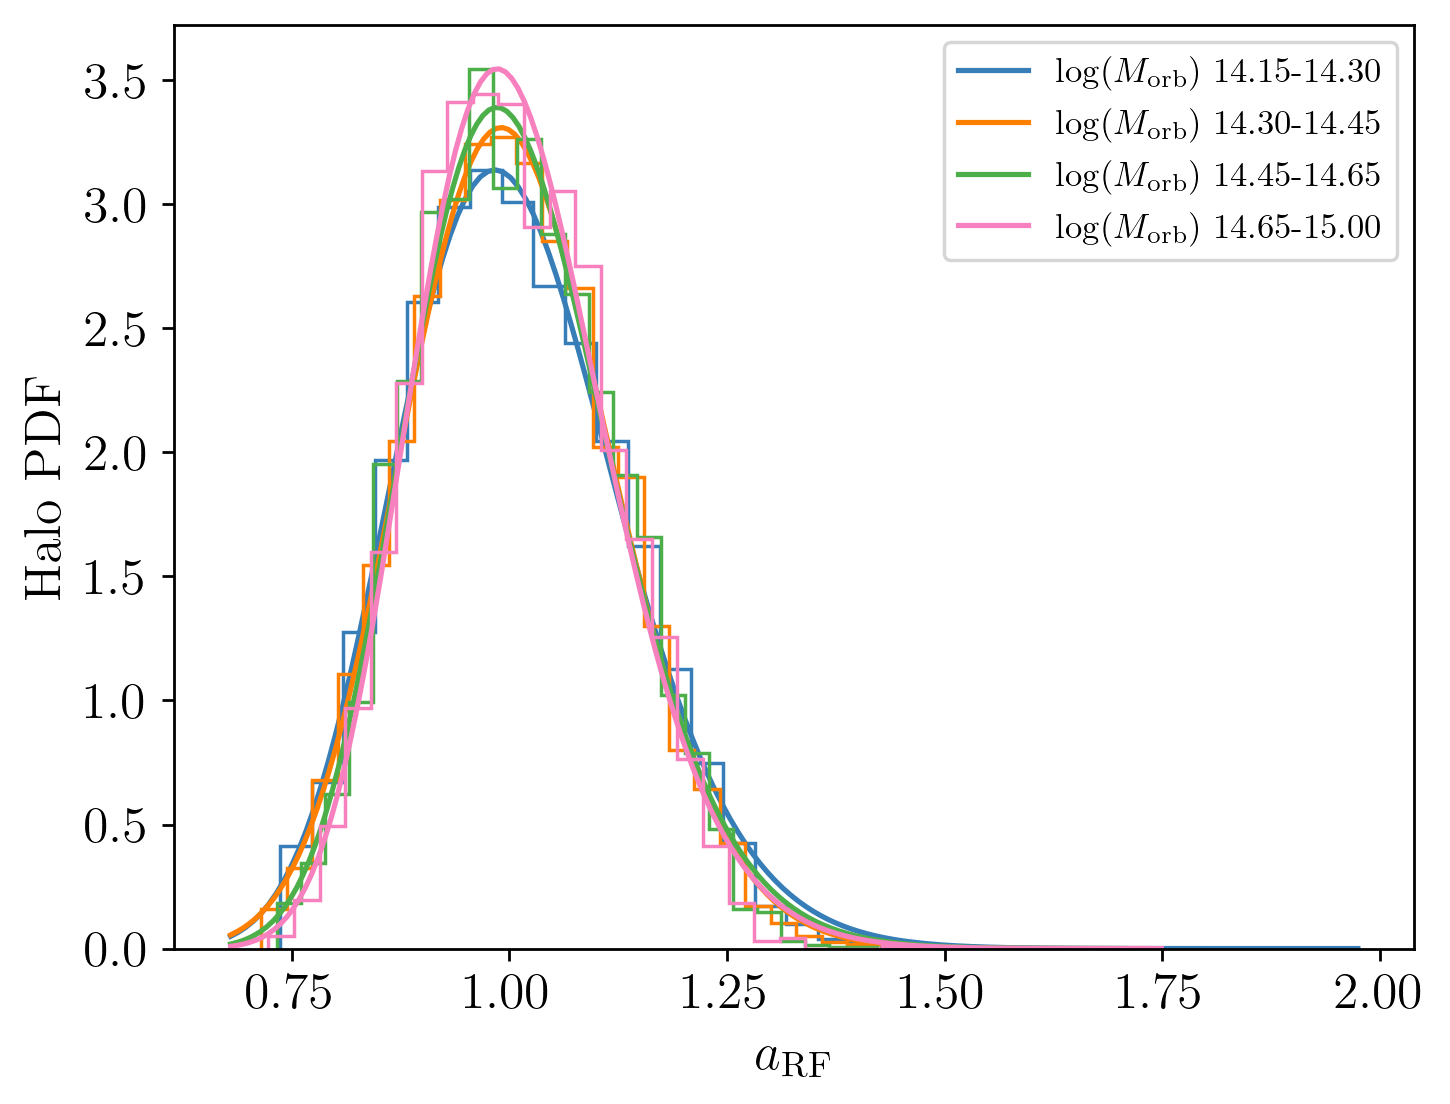

In [62]:
# Plot P(aRF | Morb)
latex()

c = 0 # Color counter
M = []
S = []
A = []
for i in [5, 6, 7, 8]:
    bin_a = aRF[Morb_mask][mbin_indices[Morb_mask] == i]
    hist, bins, __ = plt.hist(bin_a, histtype='step', bins=25, color=COLORS[c], density=True)
    m = np.mean(np.log(bin_a))
    s = np.std(np.log(bin_a))

    # Fit gaussian to each histogram
    x = np.linspace(0.68, 1.2 * np.max(bin_a), num=150)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    popt, __ = curve_fit(lognormal_gaussian, bin_centers, hist, p0=[m, s, -np.min(bin_a)])
    mu, sig, a = popt
    print(a)

    M.append(mu)
    S.append(sig)
    A.append(a)

    plt.plot(x, lognormal_gaussian(x, mu, sig, a), label='$\\log(M_{\\rm orb})$ ' + MASS_BIN_STRS[i], color=COLORS[c])
    c += 1

plt.xlabel('$a_{\\rm RF}$', fontsize=15)
plt.ylabel('Halo PDF', fontsize=15)

plt.legend()

In [63]:
# Integrate P(aRF) curves to determine expectation value of ln(a0-aRF) | Morb
def u(aRF, M, S, a):
    return (1 / (np.sqrt(2 * np.pi) * S * (aRF - a))) * np.exp(-((np.log(aRF - a) - M) ** 2) / (2 * (S ** 2))) * np.log(ARF_0 - aRF)

u_expect = np.zeros(4)
for i in range(4):
    u_expect[i] = quad(u, A[i], ARF_0, args=(M[i], S[i], A[i]))[0]

print(np.average(u_expect))
print(np.std(u_expect))

-0.11212935783839653
0.002718124372871053


In [64]:
0.018 -0.112 # From Eqns (20) and (22)

-0.094

FIGURE 6. Visual representation of the relationships between $r_{\rm h}$, $\alpha_{\infty}$, $M_{\rm orb}$, and $a_{\rm RF}$. Both plots have a scatter of points representing the best-fit $r_{\rm h}$ and $\alpha_{\infty}$ from the fitting routine described in Section 3 for each halo in our catalog. \textbf{Left:} The points are color-coded by log of their mass, with the red lines representing \eqref{eq: alpha_inf_rh_relation} with given values of fixed mass. The numbers under the lines are $\log M_{\rm orb}$, corresponding to the numbers in the colorbar. \textbf{Right:} The points are color-coded by each halo's $a_{\rm RF}$, with the red lines representing \eqref{eq:R_aRF_relation}.

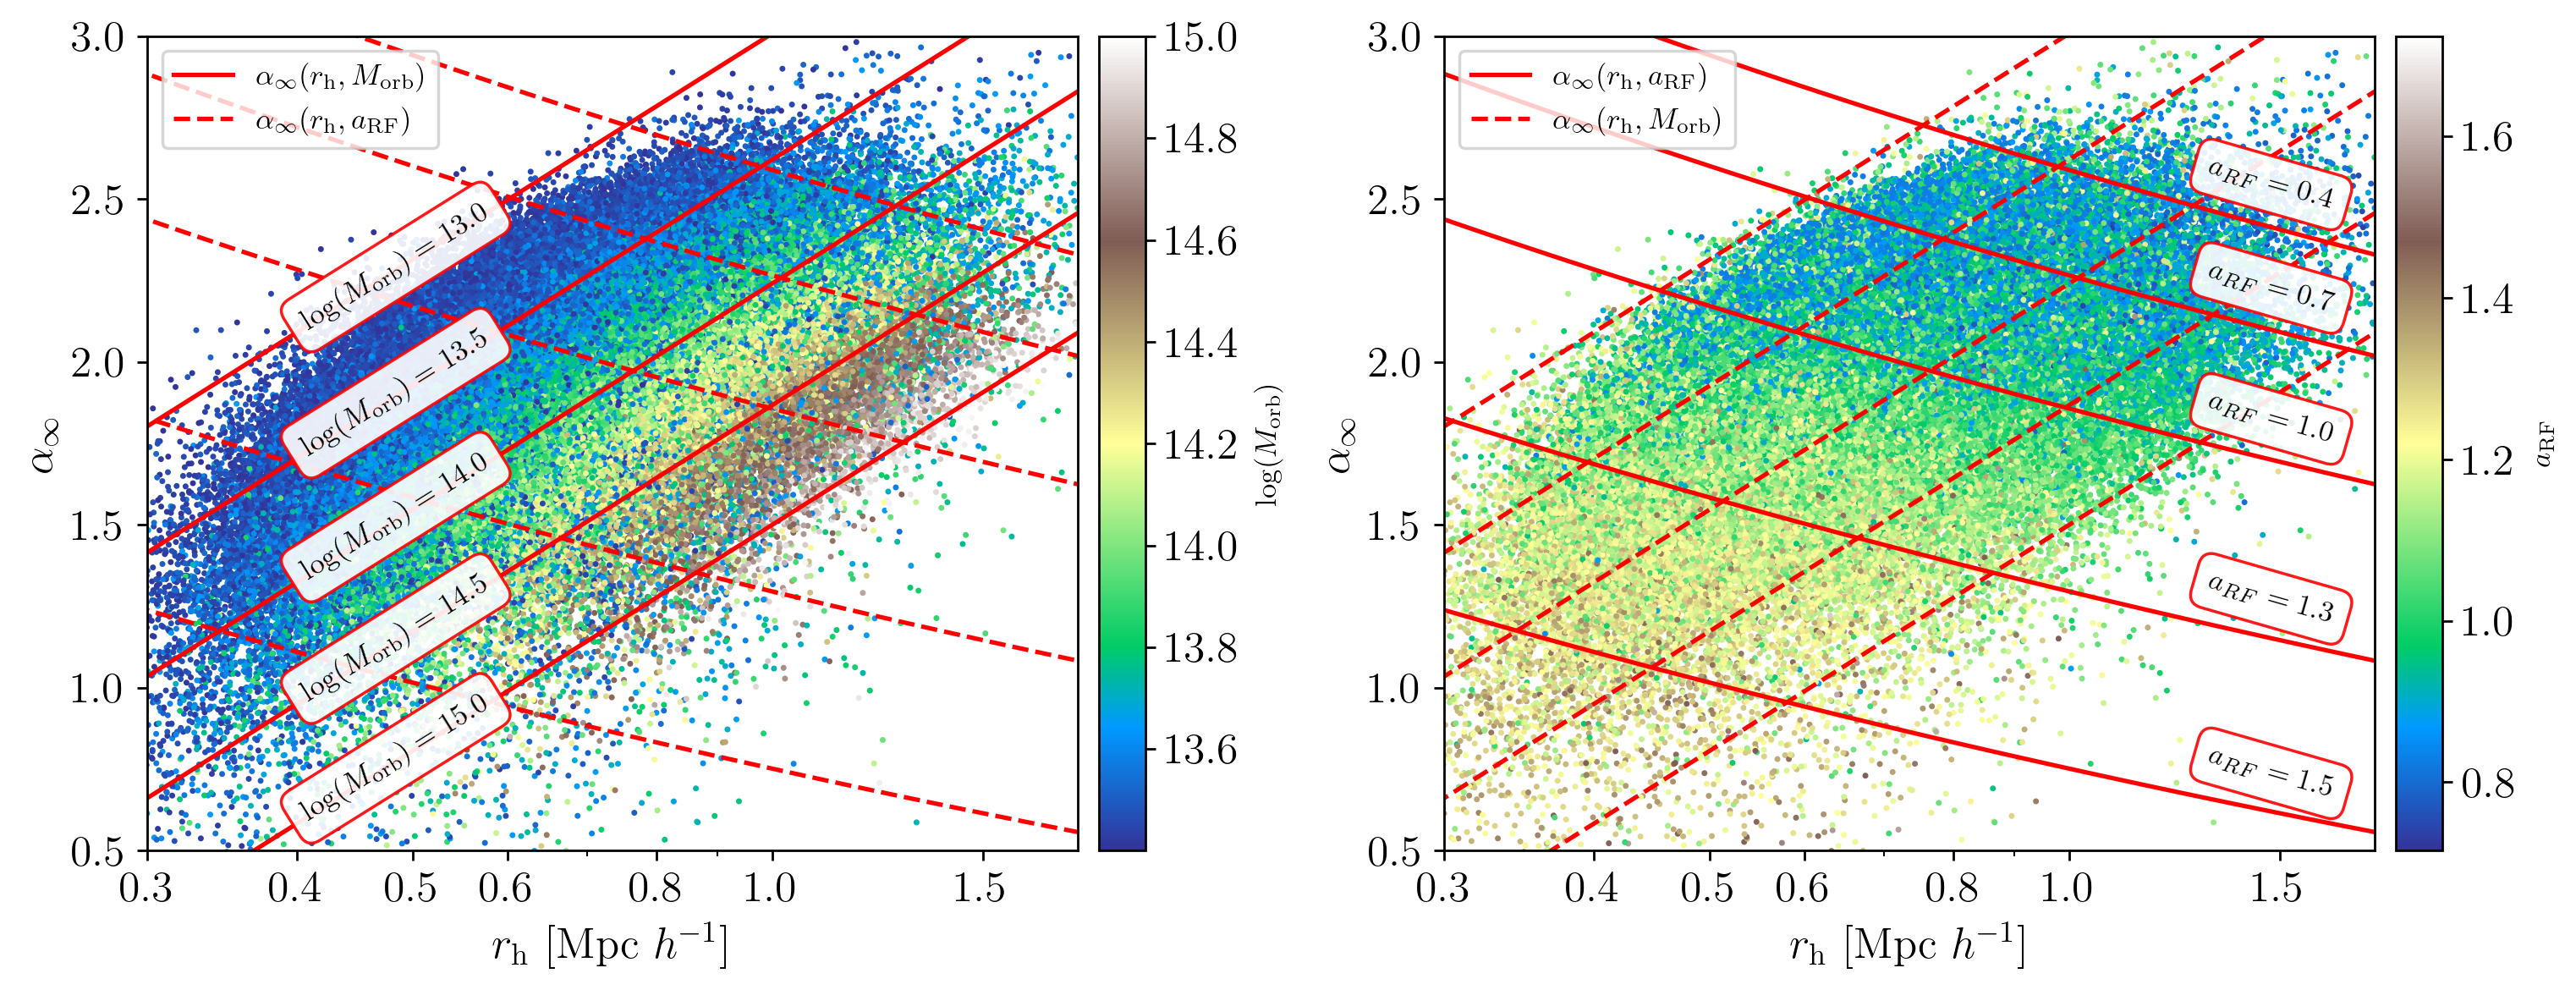

In [65]:
from matplotlib.ticker import ScalarFormatter
from matplotlib import colors, font_manager
latex()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.5)

sim_rh = SIMULT_PARAMS['rh'][()]
sim_alpha_inf = SIMULT_PARAMS['alpha_inf'][()]
log_Morb = np.log10(Morb)

cmap = 'terrain'
norm = colors.Normalize(vmin=np.min(log_Morb), vmax=15)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.1)

# Left panel
ax[0].scatter(sim_rh, sim_alpha_inf, s=1, c=log_Morb, cmap=cmap)

ax[0].set_xlabel('$r_{\\rm h}$ [Mpc $h^{-1}$]', fontsize=15)
ax[0].set_ylabel('$\\alpha_{\\infty}$', fontsize=15)

ax[0].set_xscale('log')
ax[0].set_ylim(0.5, 3.0)
ax[0].set_xlim(0.3, 1.8)
# ax[0].xaxis.set_major_formatter(ScalarFormatter())
# ax[0].xaxis.set_minor_formatter(ScalarFormatter())
ax[0].set_xticks([0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5])
ax[0].set_xticklabels(['0.3', '0.4', '0.5', '0.6', '0.8', '1.0', '1.5'])

Morb_arr = np.array([13.0, 13.5, 14.0, 14.5, 15.0])
aRF_arr = np.array([0.4, 0.7, 1.0, 1.3, 1.5])
rh_arr = np.logspace(np.log(0.3), np.log(2.0), num=100)
for i, M in enumerate(Morb_arr):
    ax[0].text(0.4, alpha_inf(0.4, 10**M)+0.01, f'$\\log(M_{{\\rm orb}}) = {M}$', color='black', rotation=32, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.5'))
    if i == 0:
        ax[0].plot(rh_arr, alpha_inf(rh_arr, 10**M), c='r', label='$\\alpha_{\\infty}(r_{\\rm h}, M_{\\rm orb})$')
    else:
        ax[0].plot(rh_arr, alpha_inf(rh_arr, 10**M), c='r')

# TEST: Grid lines
for i, a in enumerate(aRF_arr):
    if i == 0:
        ax[0].plot(rh_arr, alpha_inf_aRF(rh_arr, a), c='r', linestyle='--', label='$\\alpha_{\\infty}(r_{\\rm h}, a_{\\rm RF})$')
    else:
        ax[0].plot(rh_arr, alpha_inf_aRF(rh_arr, a), c='r', linestyle='--')
    
ax[0].legend()
fig.colorbar(sm, label='$\\log(M_{\\rm orb})$', cax=cax)

# Right panel
norm = colors.Normalize(vmin=np.min(aRF), vmax=np.max(aRF))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.1)

ax[1].scatter(sim_rh, sim_alpha_inf, s=1, c=aRF, cmap=cmap)

ax[1].set_xlabel('$r_{\\rm h}$ [Mpc $h^{-1}$]', fontsize=15)
ax[1].set_ylabel('$\\alpha_{\\infty}$', fontsize=15)

ax[1].set_xscale('log')
ax[1].set_ylim(0.5, 3.0)
ax[1].set_xlim(0.3, 1.8)
# ax[1].xaxis.set_major_formatter(ScalarFormatter())
# ax[1].xaxis.set_minor_formatter(ScalarFormatter())
ax[1].set_xticks([0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5])
ax[1].set_xticklabels(['0.3', '0.4', '0.5', '0.6', '0.8', '1.0', '1.5'])

for i, a in enumerate(aRF_arr):
    ax[1].text(1.3, alpha_inf_aRF(1.3, a), f'$a_{{RF}} = {a}$', color='black', rotation=-16, 
               bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.5'))
    if i == 0:
        ax[1].plot(rh_arr, alpha_inf_aRF(rh_arr, a), c='r', label='$\\alpha_{\\infty}(r_{\\rm h}, a_{\\rm RF})$')
    else:
        ax[1].plot(rh_arr, alpha_inf_aRF(rh_arr, a), c='r')

# TEST: Grid lines
for i, M in enumerate(Morb_arr):
    if i == 0:
        ax[1].plot(rh_arr, alpha_inf(rh_arr, 10**M), c='r', linestyle='--', label='$\\alpha_{\\infty}(r_{\\rm h}, M_{\\rm orb})$')
    else:
        ax[1].plot(rh_arr, alpha_inf(rh_arr, 10**M), c='r', linestyle='--')

ax[1].legend()
fig.colorbar(sm, label='$a_{\\rm RF}$', cax=cax)

TABLE 2. Fitted values of the slopes and y-intercepts from Figures 2 and 4, as well as the intrinsic scatters and slopes from Figure 7.

In [66]:
# Calculate jackknife errors for the parameters in every fit done for these figures, by splitting haloes into 8 octants, taking away one octant, and performing the fits without 
# that octant 8 times

# Mask haloes into octants 
halo_x = HALO_CATALOG['x'][HALO_MASS_MASK][:192042]
halo_y = HALO_CATALOG['y'][HALO_MASS_MASK][:192042]
halo_z = HALO_CATALOG['z'][HALO_MASS_MASK][:192042]

jk_masks = np.array([(halo_x > 500) & (halo_y > 500) & (halo_z > 500), 
                    (halo_x < 500) & (halo_y > 500) & (halo_z > 500), 
                    (halo_x > 500) & (halo_y < 500) & (halo_z > 500), 
                    (halo_x > 500) & (halo_y > 500) & (halo_z < 500), 
                    (halo_x < 500) & (halo_y < 500) & (halo_z > 500), 
                    (halo_x < 500) & (halo_y > 500) & (halo_z < 500), 
                    (halo_x > 500) & (halo_y < 500) & (halo_z < 500), 
                    (halo_x < 500) & (halo_y < 500) & (halo_z < 500)])

In [ ]:
s_alpha_jks = np.zeros(8)
alpha0_jks = np.zeros(8)
s_aRF_jks = np.zeros(8)
a0_jks = np.zeros(8)

for i in range(8):
    result = minimize(num_cost, [1, 0], bounds=[(0.5, 1.5), (-0.5, 0.5)], method='simplex', args=(lnR[~jk_masks[i]], delta_alph[~jk_masks[i]])) # Fit from Figure 2
    s_alpha_jks[i], alpha0_jks[i] = result.x

    result = minimize(num_cost, [-1.0, 1.9], bounds=[(-1.001, -0.999), (1.5, 2)], method='simplex', args=(aRF[Morb_mask][~jk_masks[i][Morb_mask]], 
                                                                                                        R[Morb_mask][~jk_masks[i][Morb_mask]])) # Fit from Figure 4
    s_aRF_jks[i], a0_jks[i] = result.x

1.9205587201318701
1.9093648196924191
1.9219161372261013
1.9105103648680453
1.9093648196924191
1.9093648196924191
1.9093648196924191
1.9127842991827269


In [68]:
print(f'Error in s_alpha is {jk_error(s_alpha_jks)}')
print(f'Error in alpha0 is {jk_error(alpha0_jks)}')
print(f'Error in s_aRF is {jk_error(s_aRF_jks)}')
print(f'Error in a0 is {jk_error(a0_jks)}')

Error in s_alpha is 0.0208951712217638
Error in alpha0 is 0.0026544942005671305
Error in s_aRF is 0.0011624300885347135
Error in a0 is 0.013084449452491178
